In [1]:
"""
Housing Price Prediction - Exploratory Data Analysis

This notebook provides a comprehensive exploration of our housing dataset,
identifying patterns, outliers, and data quality issues that will inform
our modeling approach.

Author: [Your Name]
Date: [Current Date]
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings

# Visualization setup
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

warnings.filterwarnings('ignore')

print("📊 Housing Price Prediction - Data Exploration")
print("=" * 50)

📊 Housing Price Prediction - Data Exploration


In [2]:
from src.data.load_data import load_housing_data

# Load the data
df = load_housing_data()

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\n🔍 First 5 rows:")
display(df.head())

print("\n📋 Column Information:")
display(df.info())

2025-07-28 16:12:33,855 - src.data.load_data - INFO - Loading housing data from data/raw/housing_data.csv
2025-07-28 16:12:33,894 - src.data.load_data - INFO - Loaded 10000 records with 14 columns
Dataset Shape: 10,000 rows × 14 columns

🔍 First 5 rows:


,price,square_feet,bedrooms,bathrooms,lot_size,age,neighborhood,property_type,condition,garage,pool,fireplace,sale_date,days_on_market
0,382801.00,1470.00,4,3.00,14688.00,9.00,Industrial,Single Family,3.00,1.00,0,0,2023-05-15,1
1,892456.00,1704.00,3,2.00,NaN,11.00,Waterfront,Condo,2.00,1.00,0,0,2023-09-11,28
2,2602644.00,3336.00,8,6.00,3254.00,3.00,Waterfront,Single Family,4.00,2.00,0,0,2022-12-16,3
3,695784.00,1419.00,3,2.50,7730.00,7.00,Historic,Single Family,3.00,1.00,0,1,2025-02-17,15
4,1789016.00,2243.00,5,3.50,3863.00,7.00,Waterfront,Single Family,4.00,1.00,0,0,2025-05-25,1



📋 Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   price           10000 non-null  float64       
 1   square_feet     10000 non-null  float64       
 2   bedrooms        10000 non-null  int64         
 3   bathrooms       10000 non-null  float64       
 4   lot_size        8396 non-null   float64       
 5   age             10000 non-null  float64       
 6   neighborhood    10000 non-null  object        
 7   property_type   10000 non-null  object        
 8   condition       9500 non-null   float64       
 9   garage          9800 non-null   float64       
 10  pool            10000 non-null  int64         
 11  fireplace       10000 non-null  int64         
 12  sale_date       10000 non-null  datetime64[ns]
 13  days_on_market  10000 non-null  int64         
dtypes: datetime64[ns](1), float64(7)

None

In [3]:
def assess_data_quality(df):
    """Generate comprehensive data quality report."""
    
    print("🔍 DATA QUALITY ASSESSMENT")
    print("=" * 50)
    
    # Missing values
    print("\n📊 Missing Values:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing Count': missing.values,
        'Missing %': missing_pct.values
    }).sort_values('Missing %', ascending=False)
    
    display(missing_df[missing_df['Missing Count'] > 0])
    
    # Data types
    print("\n📝 Data Types:")
    dtype_df = pd.DataFrame({
        'Column': df.dtypes.index,
        'Data Type': df.dtypes.values,
        'Unique Values': [df[col].nunique() for col in df.columns]
    })
    display(dtype_df)
    
    # Basic statistics
    print("\n📈 Numerical Columns Summary:")
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    display(df[numerical_cols].describe())
    
    # Categorical columns
    print("\n📂 Categorical Columns Summary:")
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if col != 'sale_date':  # Skip date column
            print(f"\n{col}:")
            value_counts = df[col].value_counts()
            print(value_counts.head(10) if len(value_counts) > 10 else value_counts)

# Run quality assessment
assess_data_quality(df)

🔍 DATA QUALITY ASSESSMENT

📊 Missing Values:


,Column,Missing Count,Missing %
4,lot_size,1604,16.04
8,condition,500,5.00
9,garage,200,2.00



📝 Data Types:


,Column,Data Type,Unique Values
0,price,float64,9938
1,square_feet,float64,2452
2,bedrooms,int64,8
3,bathrooms,float64,14
4,lot_size,float64,5993
5,age,float64,109
6,neighborhood,object,7
7,property_type,object,4
8,condition,float64,5
9,garage,float64,3



📈 Numerical Columns Summary:


,price,square_feet,bedrooms,bathrooms,lot_size,age,condition,garage,pool,fireplace,days_on_market
count,10000.00,10000.00,10000.00,10000.00,8396.00,10000.00,9500.00,9800.00,10000.00,10000.00,10000.00
mean,789982.50,1803.20,4.02,3.04,6881.65,15.18,3.10,1.01,0.15,0.31,29.33
std,420313.30,607.00,1.74,1.34,6549.31,15.23,0.89,0.62,0.36,0.46,30.21
min,44383.40,175.60,1.00,1.00,1000.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,510276.00,1391.00,3.00,2.00,2850.75,4.00,3.00,1.00,0.00,0.00,8.00
50%,693725.00,1804.50,4.00,3.00,5015.00,11.00,3.00,1.00,0.00,0.00,20.00
75%,983252.25,2203.00,5.00,4.00,8547.50,21.00,4.00,1.00,0.00,1.00,41.00
max,15547840.00,10285.00,8.00,7.50,130556.00,134.00,5.00,2.00,1.00,1.00,276.00



📂 Categorical Columns Summary:

neighborhood:
neighborhood
Waterfront       1459
Suburbs_South    1455
University       1453
Historic         1431
Industrial       1426
Downtown         1389
Suburbs_North    1387
Name: count, dtype: int64

property_type:
property_type
Single Family    5892
Condo            2006
Townhouse        1586
Multi-Family      516
Name: count, dtype: int64


🏠 TARGET VARIABLE ANALYSIS (Price)

📊 Price Statistics:
Mean: $789,982
Median: $693,725
Standard Deviation: $420,313
Min: $44,383
Max: $15,547,840
Range: $15,503,457

📏 Quartiles:
25th percentile: $510,276
75th percentile: $983,252
Interquartile Range: $472,976


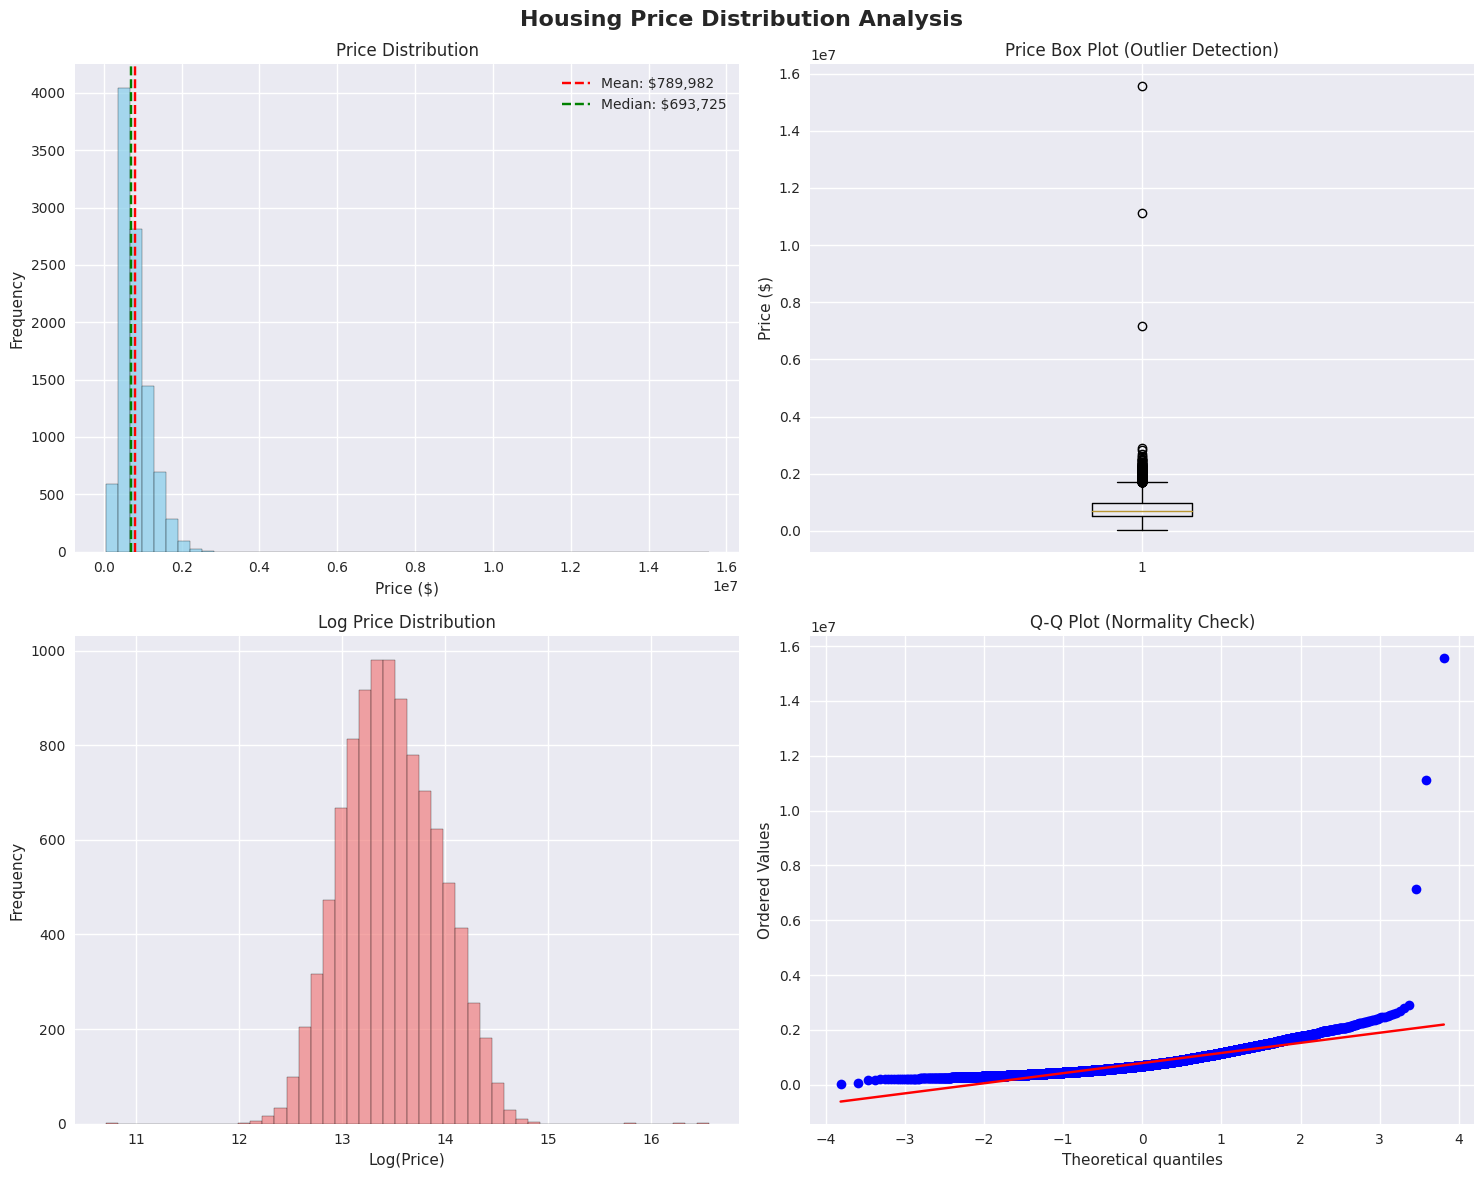


⚠️ Outlier Analysis:
Lower bound: $-199,188
Upper bound: $1,692,717
Number of outliers: 293 (2.9%)
Outlier range: $1,692,785 - $15,547,840


In [4]:
def analyze_target_variable(df, target_col='price'):
    """Comprehensive analysis of the target variable (price)."""
    
    print("🏠 TARGET VARIABLE ANALYSIS (Price)")
    print("=" * 50)
    
    prices = df[target_col].dropna()
    
    # Basic statistics
    print(f"\n📊 Price Statistics:")
    print(f"Mean: ${prices.mean():,.0f}")
    print(f"Median: ${prices.median():,.0f}")
    print(f"Standard Deviation: ${prices.std():,.0f}")
    print(f"Min: ${prices.min():,.0f}")
    print(f"Max: ${prices.max():,.0f}")
    print(f"Range: ${prices.max() - prices.min():,.0f}")
    
    # Quartiles
    print(f"\n📏 Quartiles:")
    print(f"25th percentile: ${prices.quantile(0.25):,.0f}")
    print(f"75th percentile: ${prices.quantile(0.75):,.0f}")
    print(f"Interquartile Range: ${prices.quantile(0.75) - prices.quantile(0.25):,.0f}")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Housing Price Distribution Analysis', fontsize=16, fontweight='bold')
    
    # Histogram
    axes[0, 0].hist(prices, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Price Distribution')
    axes[0, 0].set_xlabel('Price ($)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(prices.mean(), color='red', linestyle='--', label=f'Mean: ${prices.mean():,.0f}')
    axes[0, 0].axvline(prices.median(), color='green', linestyle='--', label=f'Median: ${prices.median():,.0f}')
    axes[0, 0].legend()
    
    # Box plot
    axes[0, 1].boxplot(prices)
    axes[0, 1].set_title('Price Box Plot (Outlier Detection)')
    axes[0, 1].set_ylabel('Price ($)')
    
    # Log scale histogram
    axes[1, 0].hist(np.log(prices), bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[1, 0].set_title('Log Price Distribution')
    axes[1, 0].set_xlabel('Log(Price)')
    axes[1, 0].set_ylabel('Frequency')
    
    # QQ plot for normality check
    from scipy import stats
    stats.probplot(prices, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot (Normality Check)')
    
    plt.tight_layout()
    plt.show()
    
    # Outlier detection
    Q1 = prices.quantile(0.25)
    Q3 = prices.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = prices[(prices < lower_bound) | (prices > upper_bound)]
    print(f"\n⚠️ Outlier Analysis:")
    print(f"Lower bound: ${lower_bound:,.0f}")
    print(f"Upper bound: ${upper_bound:,.0f}")
    print(f"Number of outliers: {len(outliers):,} ({len(outliers)/len(prices)*100:.1f}%)")
    
    if len(outliers) > 0:
        print(f"Outlier range: ${outliers.min():,.0f} - ${outliers.max():,.0f}")

# Analyze target variable
analyze_target_variable(df)

🔗 CORRELATION ANALYSIS

📊 Features Most Correlated with Price:
📈 square_feet: 0.321 (Moderate)
📈 bedrooms: 0.276 (Weak)
📈 bathrooms: 0.256 (Weak)
📈 condition: 0.243 (Weak)
📉 age: -0.075 (Weak)
📈 garage: 0.069 (Weak)
📈 pool: 0.056 (Weak)
📉 days_on_market: -0.016 (Weak)
📈 fireplace: 0.011 (Weak)
📉 lot_size: -0.001 (Weak)


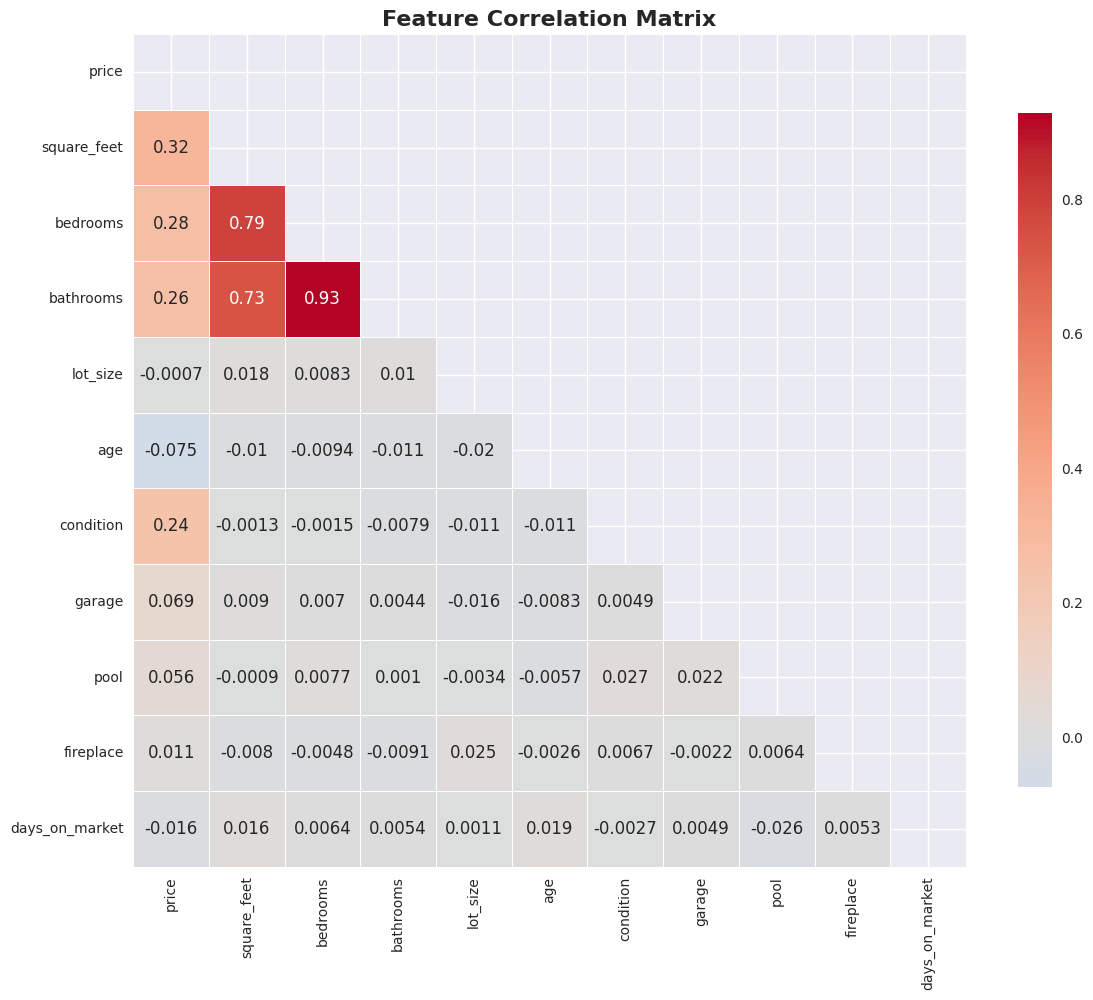

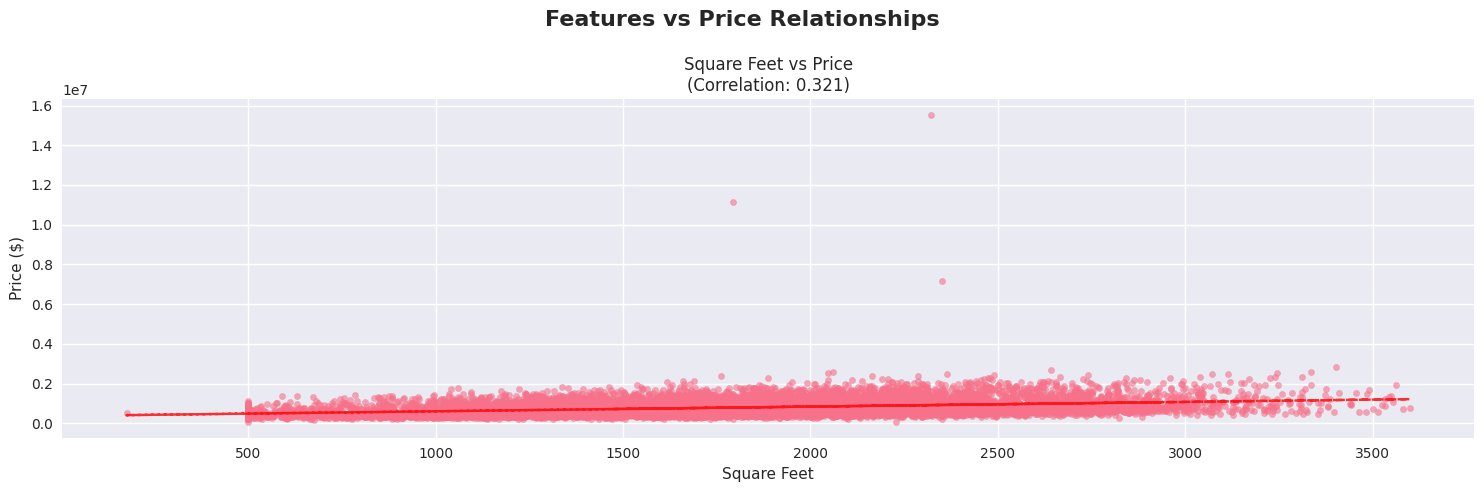

In [5]:
from scipy import stats
def analyze_correlations(df):
    """Analyze correlations between numerical features and price."""
    
    print("🔗 CORRELATION ANALYSIS")
    print("=" * 50)
    
    # Select numerical columns
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    correlation_matrix = df[numerical_cols].corr()
    
    # Price correlations
    price_correlations = correlation_matrix['price'].sort_values(key=abs, ascending=False)
    print("\n📊 Features Most Correlated with Price:")
    for feature, corr in price_correlations.items():
        if feature != 'price':
            direction = "📈" if corr > 0 else "📉"
            strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
            print(f"{direction} {feature}: {corr:.3f} ({strength})")
    
    # Correlation heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Feature vs Price scatter plots
    strong_correlations = price_correlations[abs(price_correlations) > 0.3].drop('price')
    
    if len(strong_correlations) > 0:
        n_features = len(strong_correlations)
        n_cols = min(3, n_features)
        n_rows = (n_features + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
        
        if isinstance(axes, np.ndarray):
            axes = axes.flatten()
        else:
            axes = [axes]
        
        for i, (feature, corr) in enumerate(strong_correlations.items()):
            ax = axes[i]
            
            # Remove outliers for better visualization
            feature_data = df[feature].dropna()
            price_data = df['price'][feature_data.index]
            
            # Remove extreme outliers (beyond 3 standard deviations)
            z_scores = np.abs(stats.zscore(feature_data))
            mask = z_scores < 3
            
            ax.scatter(feature_data[mask], price_data[mask], alpha=0.6, s=20)
            ax.set_xlabel(feature.replace('_', ' ').title())
            ax.set_ylabel('Price ($)')
            ax.set_title(f'{feature.replace("_", " ").title()} vs Price\n(Correlation: {corr:.3f})')
            
            # Add trend line
            z = np.polyfit(feature_data[mask], price_data[mask], 1)
            p = np.poly1d(z)
            ax.plot(feature_data[mask], p(feature_data[mask]), "r--", alpha=0.8)
        
        # Hide extra subplots
        for i in range(len(strong_correlations), len(axes)):
            axes[i].set_visible(False)
        
        plt.suptitle('Features vs Price Relationships', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

analyze_correlations(df)

📂 CATEGORICAL FEATURE ANALYSIS

🏷️ Neighborhood Analysis:
Categories: 7
Most common: Waterfront (1,459 properties)

Price by Neighborhood:


,count,mean,median,std
neighborhood,,,,
Waterfront,1459,1392208.70,1339650.00,572124.65
Downtown,1389,1023095.66,1003213.00,271247.01
Historic,1431,846597.68,826805.00,270641.12
Suburbs_North,1387,697028.60,681222.00,186081.57
Suburbs_South,1455,609196.26,597662.00,159315.98
University,1453,536011.38,526010.00,136068.12
Industrial,1426,423595.78,413358.50,108165.68


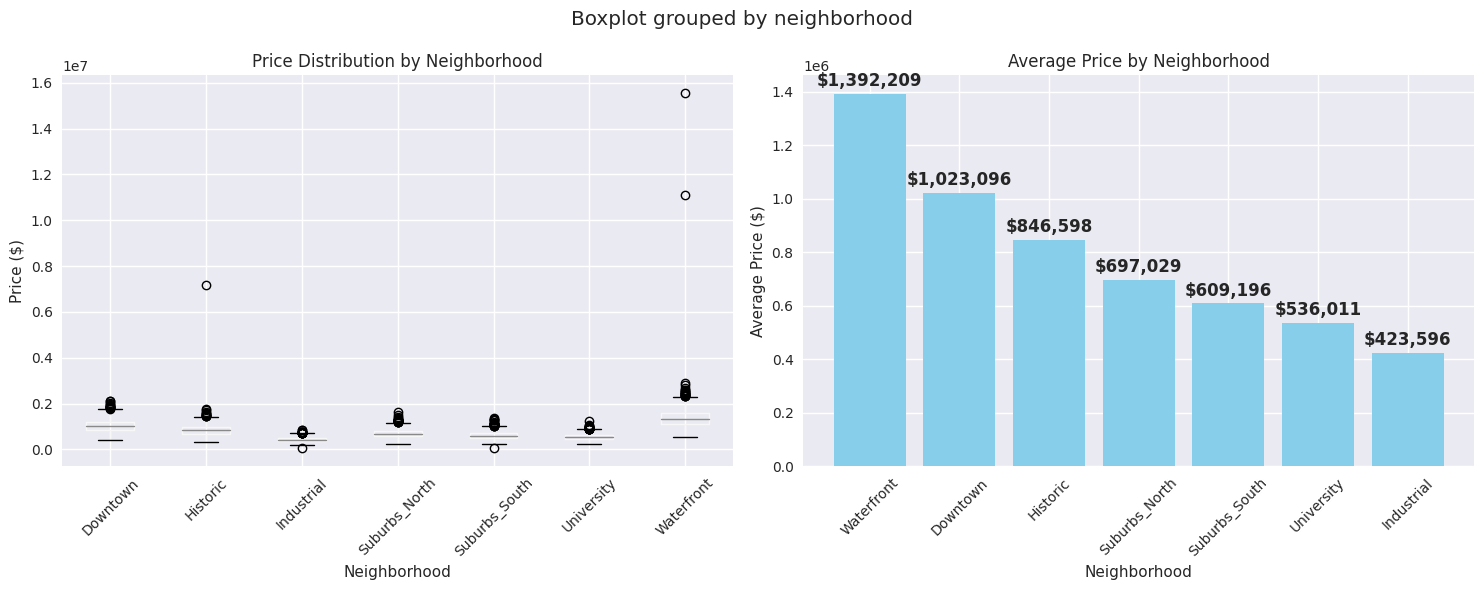


🏷️ Property Type Analysis:
Categories: 4
Most common: Single Family (5,892 properties)

Price by Property Type:


,count,mean,median,std
property_type,,,,
Multi-Family,516,910351.92,780591.00,762302.74
Single Family,5892,821458.47,724221.50,387664.38
Townhouse,1586,746336.14,663775.00,427899.20
Condo,2006,701077.24,614010.00,359734.60


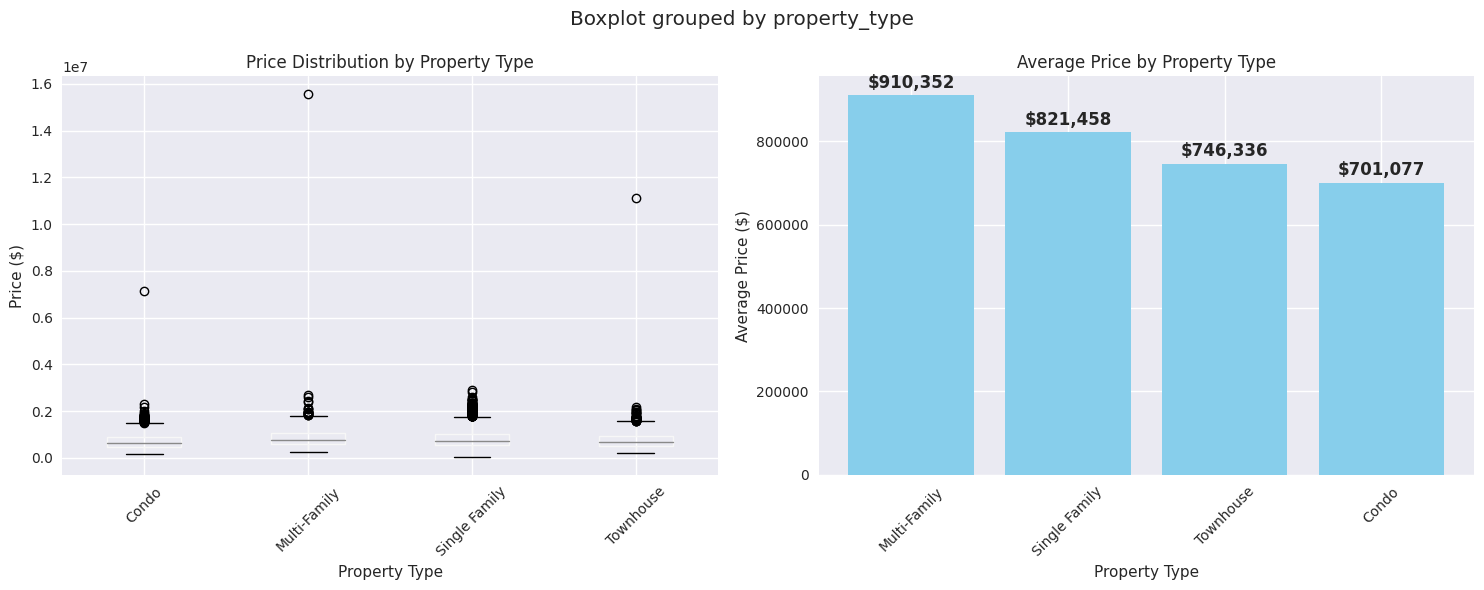

In [6]:
def analyze_categorical_features(df):
    """Analyze categorical features and their relationship with price."""
    
    print("📂 CATEGORICAL FEATURE ANALYSIS")
    print("=" * 50)
    
    categorical_cols = ['neighborhood', 'property_type']
    
    for col in categorical_cols:
        print(f"\n🏷️ {col.replace('_', ' ').title()} Analysis:")
        
        # Value counts
        value_counts = df[col].value_counts()
        print(f"Categories: {len(value_counts)}")
        print(f"Most common: {value_counts.index[0]} ({value_counts.iloc[0]:,} properties)")
        
        # Price by category
        price_by_category = df.groupby(col)['price'].agg(['count', 'mean', 'median', 'std'])
        price_by_category = price_by_category.sort_values('mean', ascending=False)
        print(f"\nPrice by {col.replace('_', ' ').title()}:")
        display(price_by_category)
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Box plot
        df.boxplot(column='price', by=col, ax=axes[0])
        axes[0].set_title(f'Price Distribution by {col.replace("_", " ").title()}')
        axes[0].set_xlabel(col.replace('_', ' ').title())
        axes[0].set_ylabel('Price ($)')
        plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
        
        # Bar plot of mean prices
        mean_prices = df.groupby(col)['price'].mean().sort_values(ascending=False)
        axes[1].bar(range(len(mean_prices)), mean_prices.values, color='skyblue')
        axes[1].set_xlabel(col.replace('_', ' ').title())
        axes[1].set_ylabel('Average Price ($)')
        axes[1].set_title(f'Average Price by {col.replace("_", " ").title()}')
        axes[1].set_xticks(range(len(mean_prices)))
        axes[1].set_xticklabels(mean_prices.index, rotation=45)
        
        # Add value labels on bars
        for i, v in enumerate(mean_prices.values):
            axes[1].text(i, v + max(mean_prices) * 0.01, f'${v:,.0f}', 
                        ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.show()

analyze_categorical_features(df)

📅 TEMPORAL ANALYSIS


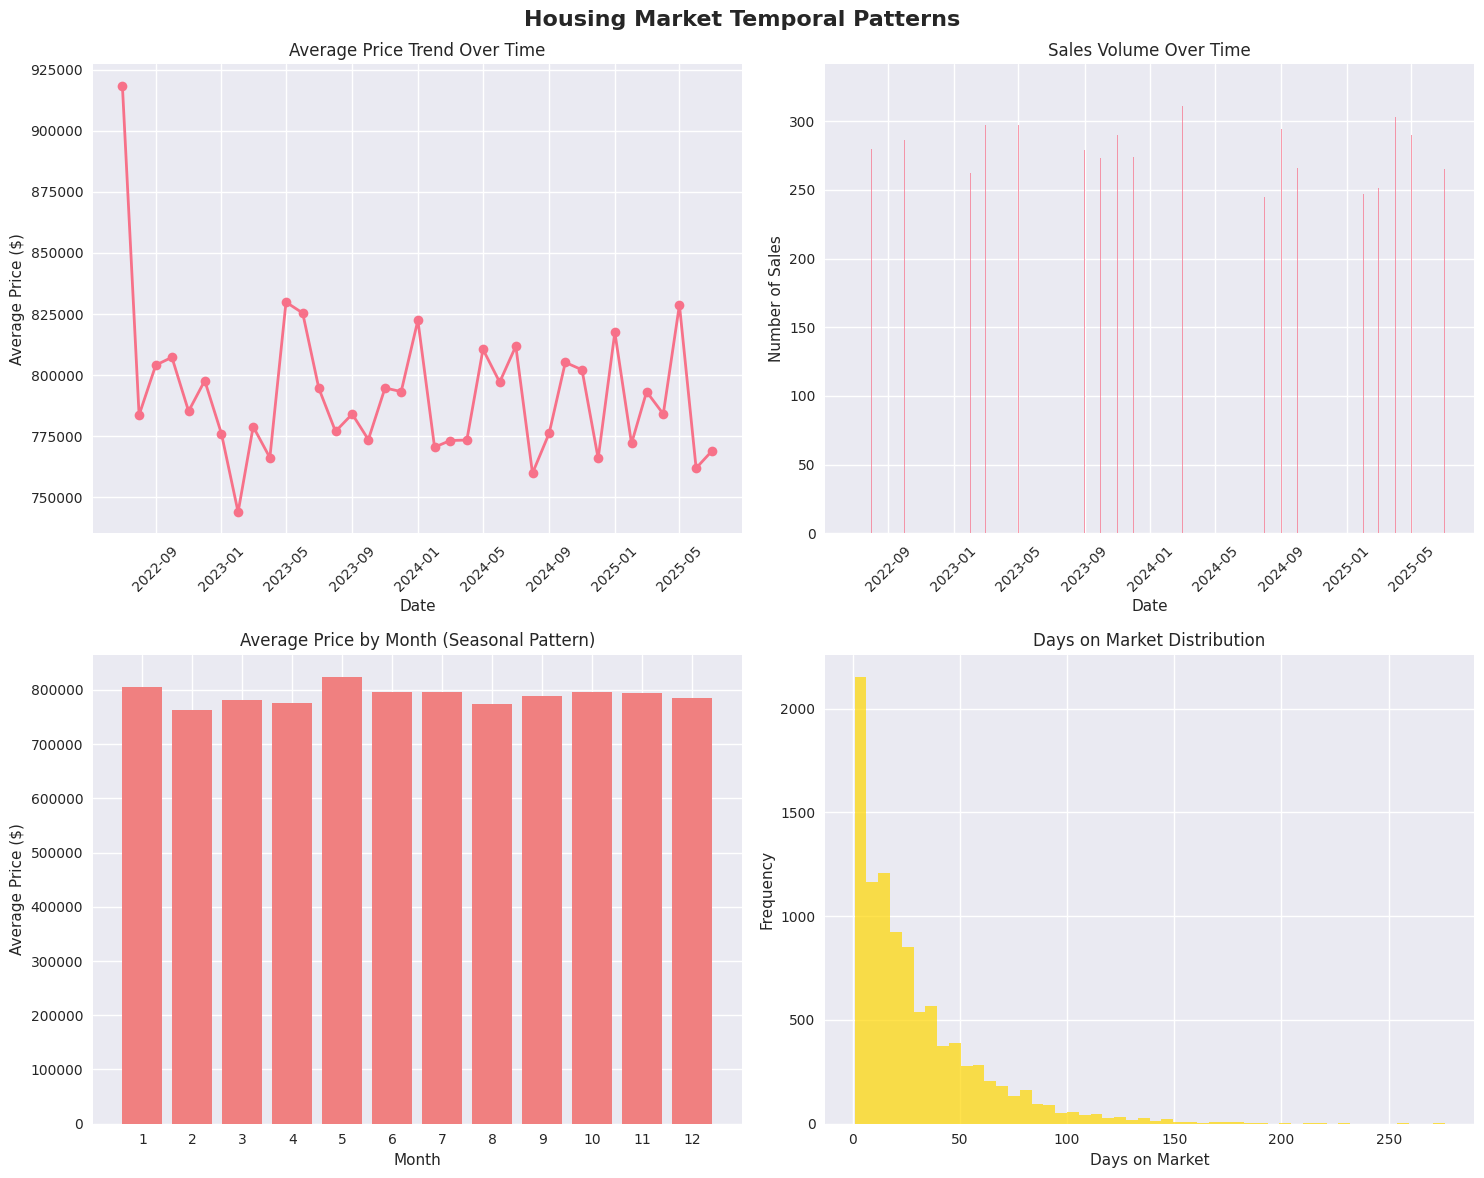


📊 Temporal Summary:
Date range: 2022-07-30 to 2025-07-28
Total time span: 1094 days
Average days on market: 29.3
Median days on market: 20.0

📈 Year-over-year price changes:
📉 2023: -1.3%
📈 2024: +0.3%
📈 2025: +0.1%


In [7]:
def analyze_temporal_patterns(df):
    """Analyze how prices change over time."""
    
    print("📅 TEMPORAL ANALYSIS")
    print("=" * 50)

    # Convert sale_date to datetime if not already
    df['sale_date'] = pd.to_datetime(df['sale_date'])
    
    # Extract time components
    df['sale_year'] = df['sale_date'].dt.year
    df['sale_month'] = df['sale_date'].dt.month
    df['sale_quarter'] = df['sale_date'].dt.quarter
    
    # Price trends over time
    monthly_prices = df.groupby(['sale_year', 'sale_month'])['price'].agg(['mean', 'count']).reset_index()
    monthly_prices['date'] = pd.to_datetime(monthly_prices.rename(columns={'sale_year': 'year', 'sale_month': 'month'})[['year', 'month']].assign(day=1))
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Housing Market Temporal Patterns', fontsize=16, fontweight='bold')
    
    # Price trend over time
    axes[0, 0].plot(monthly_prices['date'], monthly_prices['mean'], marker='o', linewidth=2)
    axes[0, 0].set_title('Average Price Trend Over Time')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Average Price ($)')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Sales volume over time
    axes[0, 1].bar(monthly_prices['date'], monthly_prices['count'], alpha=0.7)
    axes[0, 1].set_title('Sales Volume Over Time')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].set_ylabel('Number of Sales')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Seasonal patterns - by month
    monthly_avg = df.groupby('sale_month')['price'].mean()
    axes[1, 0].bar(monthly_avg.index, monthly_avg.values, color='lightcoral')
    axes[1, 0].set_title('Average Price by Month (Seasonal Pattern)')
    axes[1, 0].set_xlabel('Month')
    axes[1, 0].set_ylabel('Average Price ($)')
    axes[1, 0].set_xticks(range(1, 13))
    
    # Days on market distribution
    axes[1, 1].hist(df['days_on_market'], bins=50, alpha=0.7, color='gold')
    axes[1, 1].set_title('Days on Market Distribution')
    axes[1, 1].set_xlabel('Days on Market')
    axes[1, 1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\n📊 Temporal Summary:")
    print(f"Date range: {df['sale_date'].min().strftime('%Y-%m-%d')} to {df['sale_date'].max().strftime('%Y-%m-%d')}")
    print(f"Total time span: {(df['sale_date'].max() - df['sale_date'].min()).days} days")
    print(f"Average days on market: {df['days_on_market'].mean():.1f}")
    print(f"Median days on market: {df['days_on_market'].median():.1f}")
    
    # Price trend analysis
    yearly_change = df.groupby('sale_year')['price'].mean().pct_change().dropna()
    if len(yearly_change) > 0:
        print(f"\n📈 Year-over-year price changes:")
        for year, change in yearly_change.items():
            direction = "📈" if change > 0 else "📉"
            print(f"{direction} {year}: {change*100:+.1f}%")

analyze_temporal_patterns(df)

⚠️ OUTLIER DETECTION AND ANALYSIS

🔍 Price Outliers:
IQR method: 293 outliers (2.9%)
Z-score method: 64 outliers (0.6%)
Bounds: [-199,188, 1,692,717]

🔍 Square Feet Outliers:
IQR method: 37 outliers (0.4%)
Z-score method: 18 outliers (0.2%)
Bounds: [173, 3,421]

🔍 Lot Size Outliers:
IQR method: 518 outliers (6.2%)
Z-score method: 146 outliers (1.7%)
Bounds: [-5,694, 17,093]

🔍 Age Outliers:
IQR method: 500 outliers (5.0%)
Z-score method: 186 outliers (1.9%)
Bounds: [-22, 46]


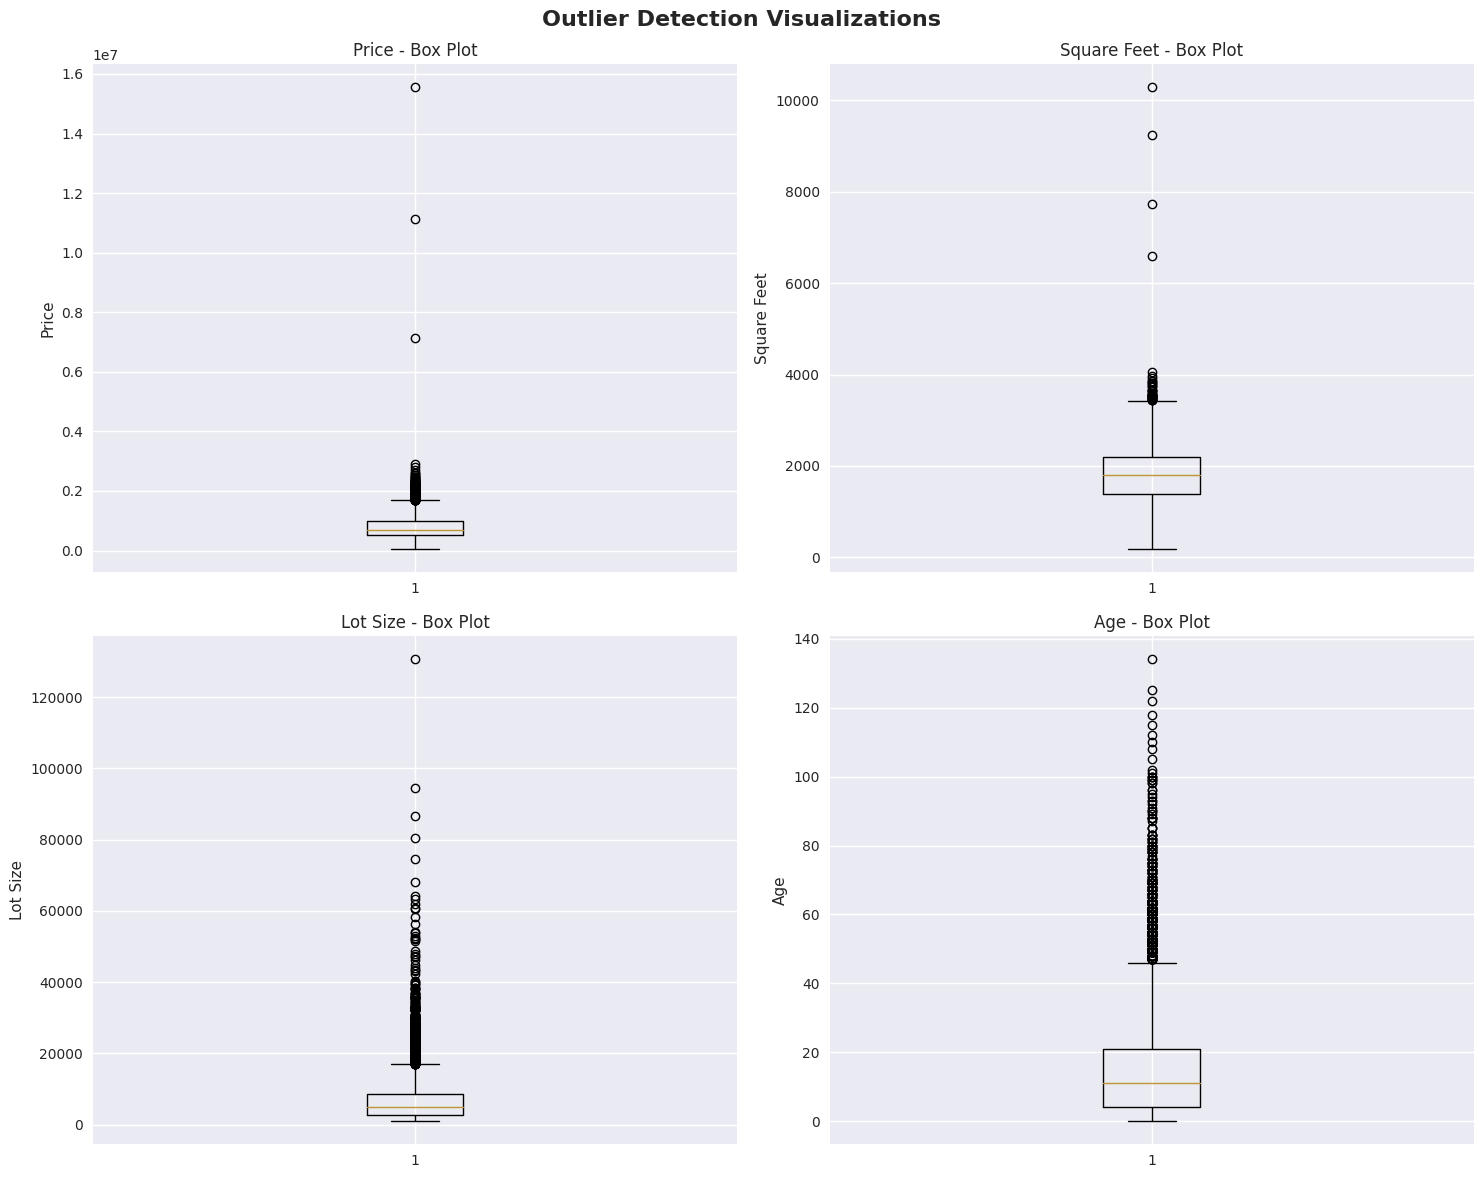


🚨 Potential Data Quality Issues:
Very cheap houses (<$50K): 2 properties
Very expensive houses (>$2M): 80 properties
Very small houses (<300 sqft): 1 properties
Very large houses (>10K sqft): 1 properties
Crowded properties (<100 sqft/bedroom): 1 properties
Very old properties (>200 years): 0 properties


In [8]:
def detect_and_analyze_outliers(df):
    """Comprehensive outlier detection and analysis."""
    
    print("⚠️ OUTLIER DETECTION AND ANALYSIS")
    print("=" * 50)
    
    numerical_cols = ['price', 'square_feet', 'lot_size', 'age']
    outlier_summary = {}
    
    for col in numerical_cols:
        if col in df.columns:
            data = df[col].dropna()
            
            # IQR method
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers_iqr = data[(data < lower_bound) | (data > upper_bound)]
            
            # Z-score method (3 standard deviations)
            z_scores = np.abs(stats.zscore(data))
            outliers_zscore = data[z_scores > 3]
            
            outlier_summary[col] = {
                'total_values': len(data),
                'iqr_outliers': len(outliers_iqr),
                'iqr_percentage': len(outliers_iqr) / len(data) * 100,
                'zscore_outliers': len(outliers_zscore),
                'zscore_percentage': len(outliers_zscore) / len(data) * 100,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound
            }
            
            print(f"\n🔍 {col.replace('_', ' ').title()} Outliers:")
            print(f"IQR method: {len(outliers_iqr):,} outliers ({len(outliers_iqr)/len(data)*100:.1f}%)")
            print(f"Z-score method: {len(outliers_zscore):,} outliers ({len(outliers_zscore)/len(data)*100:.1f}%)")
            print(f"Bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]")
    
    # Visualize outliers
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Outlier Detection Visualizations', fontsize=16, fontweight='bold')
    
    for i, col in enumerate(numerical_cols[:4]):
        if col in df.columns:
            row, col_idx = divmod(i, 2)
            
            # Box plot
            axes[row, col_idx].boxplot(df[col].dropna())
            axes[row, col_idx].set_title(f'{col.replace("_", " ").title()} - Box Plot')
            axes[row, col_idx].set_ylabel(col.replace('_', ' ').title())
    
    plt.tight_layout()
    plt.show()
    
    # Identify potential data quality issues
    print(f"\n🚨 Potential Data Quality Issues:")
    
    # Extreme values that might be errors
    if 'price' in df.columns:
        very_cheap = df[df['price'] < 50000]
        very_expensive = df[df['price'] > 2000000]
        print(f"Very cheap houses (<$50K): {len(very_cheap)} properties")
        print(f"Very expensive houses (>$2M): {len(very_expensive)} properties")
    
    if 'square_feet' in df.columns:
        very_small = df[df['square_feet'] < 300]
        very_large = df[df['square_feet'] > 10000]
        print(f"Very small houses (<300 sqft): {len(very_small)} properties")
        print(f"Very large houses (>10K sqft): {len(very_large)} properties")
    
    # Properties that don't make sense
    if 'bedrooms' in df.columns and 'square_feet' in df.columns:
        crowded = df[df['square_feet'] / df['bedrooms'] < 100]
        print(f"Crowded properties (<100 sqft/bedroom): {len(crowded)} properties")
    
    if 'age' in df.columns:
        very_old = df[df['age'] > 200]
        print(f"Very old properties (>200 years): {len(very_old)} properties")
    
    return outlier_summary

outlier_summary = detect_and_analyze_outliers(df)

🔧 FEATURE ENGINEERING OPPORTUNITIES

📊 New Feature Correlations with Price:
price_per_sqft: 0.659 (Strong Positive)
bath_bed_ratio: -0.082 (Weak Negative)
lot_per_house_size: -0.120 (Weak Negative)

📂 Categorical Feature Analysis:

Price by Age Category:


,mean,count
age_category,,
New,851272.41,2712
Modern,772568.99,4380
Mature,765353.08,2204
Old,680836.84,356
Historic,618899.55,11



Price by Size Category:


,mean,count
size_category,,
Small,544332.29,910
Medium,669637.83,2187
Large,827511.71,5714
Mansion,1018993.07,1189


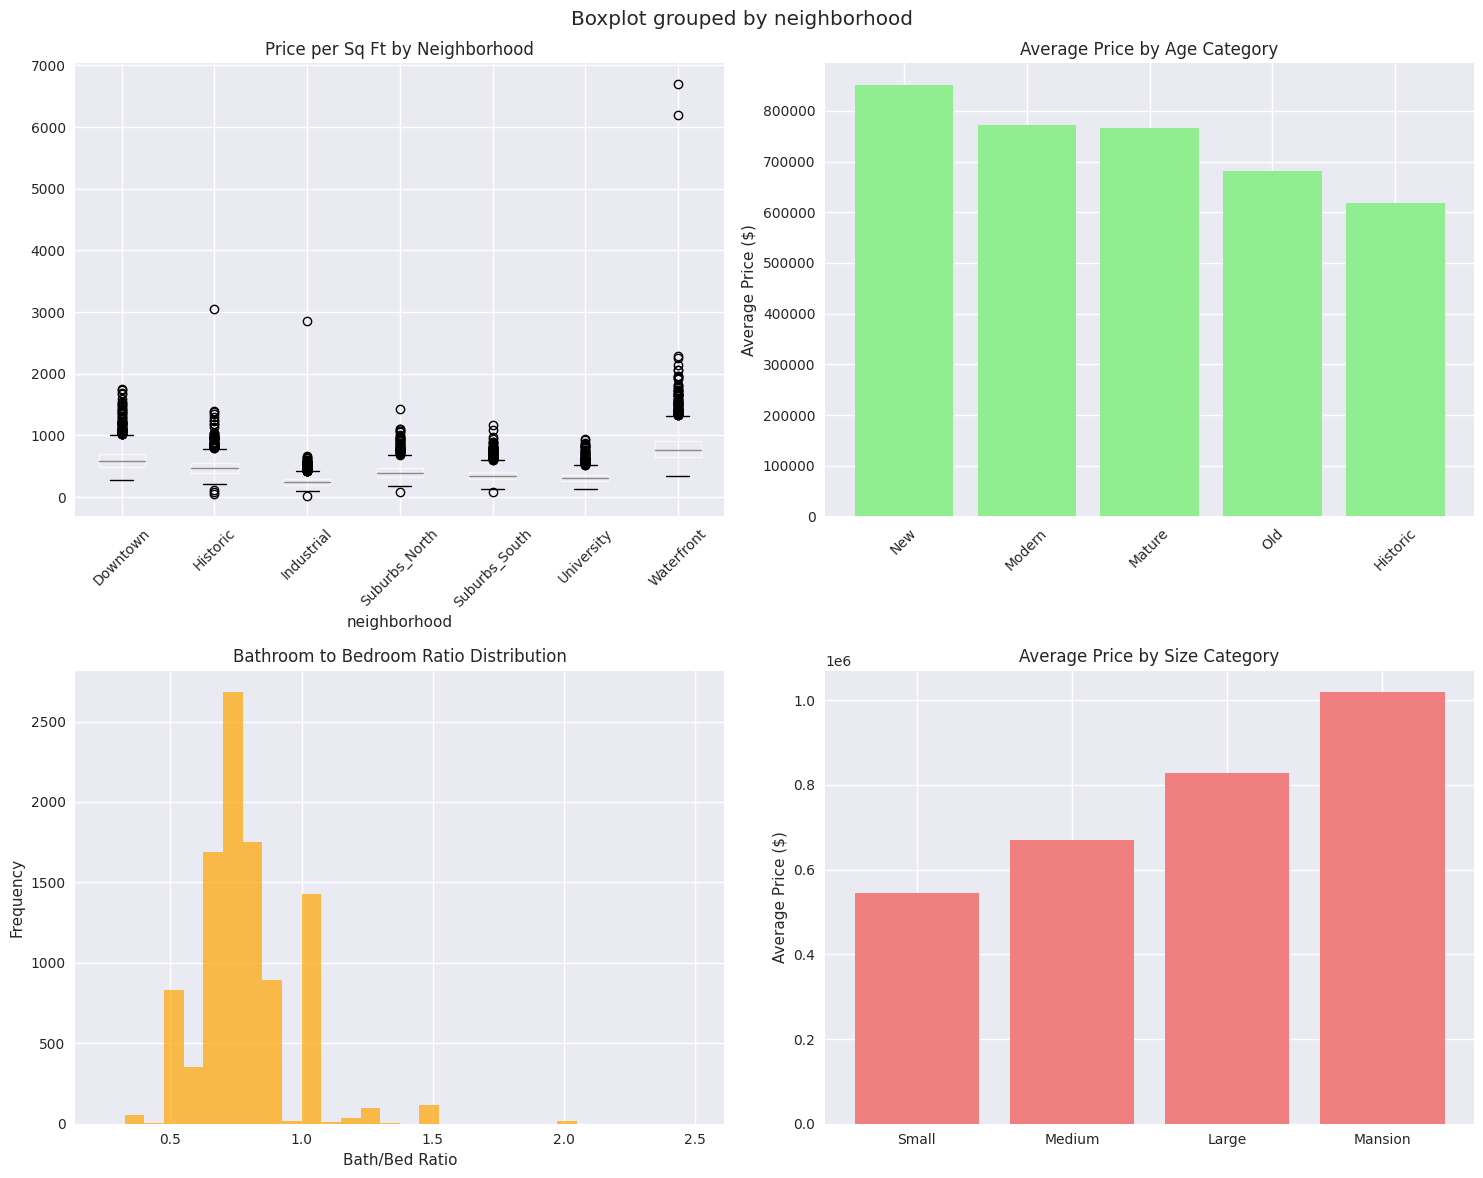


💡 Feature Engineering Recommendations:
1. Price per square foot shows strong neighborhood variation - good feature
2. Age categories may be more useful than raw age values
3. Size categories could help capture non-linear size effects
4. Bathroom/bedroom ratio might indicate luxury vs utility
5. Consider interaction features (e.g., neighborhood × size)


In [9]:
def analyze_feature_engineering_opportunities(df):
    """Identify opportunities for feature engineering."""
    
    print("🔧 FEATURE ENGINEERING OPPORTUNITIES")
    print("=" * 50)
    
    # Create some potential new features and analyze their relationships
    df_temp = df.copy()
    
    # Price per square foot
    df_temp['price_per_sqft'] = df_temp['price'] / df_temp['square_feet']
    
    # Age categories
    df_temp['age_category'] = pd.cut(df_temp['age'], 
                                   bins=[0, 5, 20, 50, 100, float('inf')],
                                   labels=['New', 'Modern', 'Mature', 'Old', 'Historic'])
    
    # Size categories
    df_temp['size_category'] = pd.cut(df_temp['square_feet'],
                                    bins=[0, 1000, 1500, 2500, float('inf')],
                                    labels=['Small', 'Medium', 'Large', 'Mansion'])
    
    # Bathroom to bedroom ratio
    df_temp['bath_bed_ratio'] = df_temp['bathrooms'] / df_temp['bedrooms']
    
    # Lot size per square foot of house
    df_temp['lot_per_house_size'] = df_temp['lot_size'] / df_temp['square_feet']
    
    # Calculate correlations with price for new features
    new_features = ['price_per_sqft', 'bath_bed_ratio', 'lot_per_house_size']
    
    print("\n📊 New Feature Correlations with Price:")
    for feature in new_features:
        if feature in df_temp.columns:
            corr = df_temp[feature].corr(df_temp['price'])
            if not np.isnan(corr):
                strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
                direction = "Positive" if corr > 0 else "Negative"
                print(f"{feature}: {corr:.3f} ({strength} {direction})")
    
    # Analyze categorical features we created
    print(f"\n📂 Categorical Feature Analysis:")
    
    # Age category analysis
    age_price = df_temp.groupby('age_category')['price'].agg(['mean', 'count'])
    print(f"\nPrice by Age Category:")
    display(age_price)
    
    # Size category analysis
    size_price = df_temp.groupby('size_category')['price'].agg(['mean', 'count'])
    print(f"\nPrice by Size Category:")
    display(size_price)
    
    # Visualize new features
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Feature Engineering Analysis', fontsize=16, fontweight='bold')
    
    # Price per square foot by neighborhood
    df_temp.boxplot(column='price_per_sqft', by='neighborhood', ax=axes[0, 0])
    axes[0, 0].set_title('Price per Sq Ft by Neighborhood')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Price by age category
    age_means = df_temp.groupby('age_category')['price'].mean()
    axes[0, 1].bar(range(len(age_means)), age_means.values, color='lightgreen')
    axes[0, 1].set_title('Average Price by Age Category')
    axes[0, 1].set_xticks(range(len(age_means)))
    axes[0, 1].set_xticklabels(age_means.index, rotation=45)
    axes[0, 1].set_ylabel('Average Price ($)')
    
    # Bath to bed ratio distribution
    axes[1, 0].hist(df_temp['bath_bed_ratio'].dropna(), bins=30, alpha=0.7, color='orange')
    axes[1, 0].set_title('Bathroom to Bedroom Ratio Distribution')
    axes[1, 0].set_xlabel('Bath/Bed Ratio')
    axes[1, 0].set_ylabel('Frequency')
    
    # Price vs size category
    size_means = df_temp.groupby('size_category')['price'].mean()
    axes[1, 1].bar(range(len(size_means)), size_means.values, color='lightcoral')
    axes[1, 1].set_title('Average Price by Size Category')
    axes[1, 1].set_xticks(range(len(size_means)))
    axes[1, 1].set_xticklabels(size_means.index)
    axes[1, 1].set_ylabel('Average Price ($)')
    
    plt.tight_layout()
    plt.show()
    
    # Recommendations
    print(f"\n💡 Feature Engineering Recommendations:")
    print("1. Price per square foot shows strong neighborhood variation - good feature")
    print("2. Age categories may be more useful than raw age values")
    print("3. Size categories could help capture non-linear size effects")
    print("4. Bathroom/bedroom ratio might indicate luxury vs utility")
    print("5. Consider interaction features (e.g., neighborhood × size)")

analyze_feature_engineering_opportunities(df)

In [10]:
def generate_data_quality_report(df):
    """Generate a comprehensive data quality report."""
    
    print("📋 COMPREHENSIVE DATA QUALITY REPORT")
    print("=" * 60)
    
    report = {
        'dataset_overview': {},
        'missing_data': {},
        'data_types': {},
        'outliers': {},
        'duplicates': {},
        'recommendations': []
    }
    
    # Dataset Overview
    report['dataset_overview'] = {
        'total_records': len(df),
        'total_features': len(df.columns),
        'memory_usage': f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB",
        'date_range': f"{df['sale_date'].min()} to {df['sale_date'].max()}"
    }
    
    print(f"\n📊 Dataset Overview:")
    for key, value in report['dataset_overview'].items():
        print(f"  {key.replace('_', ' ').title()}: {value}")
    
    # Missing Data Analysis
    missing_counts = df.isnull().sum()
    missing_percentages = (missing_counts / len(df)) * 100
    
    report['missing_data'] = {
        'columns_with_missing': sum(missing_counts > 0),
        'total_missing_values': missing_counts.sum(),
        'missing_percentage': missing_percentages.sum() / len(df.columns)
    }
    
    print(f"\n❌ Missing Data:")
    print(f"  Columns with missing data: {report['missing_data']['columns_with_missing']}")
    print(f"  Total missing values: {report['missing_data']['total_missing_values']:,}")
    
    # Missing data by column
    if missing_counts.sum() > 0:
        print(f"\n  Missing data by column:")
        for col, count in missing_counts[missing_counts > 0].items():
            percentage = (count / len(df)) * 100
            print(f"    {col}: {count:,} ({percentage:.1f}%)")
    
    # Data Type Analysis
    dtype_counts = df.dtypes.value_counts()
    report['data_types'] = dict(dtype_counts)
    
    print(f"\n📝 Data Types:")
    for dtype, count in dtype_counts.items():
        print(f"  {dtype}: {count} columns")
    
    # Duplicate Analysis
    duplicate_count = df.duplicated().sum()
    report['duplicates'] = {
        'duplicate_rows': duplicate_count,
        'duplicate_percentage': (duplicate_count / len(df)) * 100
    }
    
    print(f"\n🔄 Duplicates:")
    print(f"  Duplicate rows: {duplicate_count:,} ({duplicate_count/len(df)*100:.1f}%)")
    
    # Data Quality Score
    quality_score = 100
    
    # Penalize for missing data
    quality_score -= min(missing_percentages.mean() * 2, 30)
    
    # Penalize for duplicates
    quality_score -= min((duplicate_count / len(df)) * 100 * 5, 20)
    
    # Penalize for extreme outliers
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    outlier_percentage = 0
    for col in numerical_cols:
        if col in df.columns:
            z_scores = np.abs(stats.zscore(df[col].dropna()))
            extreme_outliers = sum(z_scores > 4)  # Very extreme outliers
            outlier_percentage += (extreme_outliers / len(df)) * 100
    
    quality_score -= min(outlier_percentage, 15)
    quality_score = max(quality_score, 0)
    
    print(f"\n⭐ Overall Data Quality Score: {quality_score:.1f}/100")
    
    # Recommendations
    recommendations = []
    
    if missing_percentages.mean() > 5:
        recommendations.append("Address missing data through imputation or feature engineering")
    
    if duplicate_count > 0:
        recommendations.append("Investigate and remove duplicate records")
    
    if outlier_percentage > 2:
        recommendations.append("Investigate extreme outliers for data entry errors")
    
    if len(df) < 1000:
        recommendations.append("Consider collecting more data for robust model training")
    
    if df['price'].std() / df['price'].mean() > 1:
        recommendations.append("High price variability - consider log transformation")
    
    recommendations.extend([
        "Create train/validation/test splits to prevent data leakage",
        "Document any data preprocessing decisions",
        "Set up data monitoring for production deployment"
    ])
    
    print(f"\n💡 Recommendations:")
    for i, rec in enumerate(recommendations, 1):
        print(f"  {i}. {rec}")
    
    return report

# Generate the comprehensive report
quality_report = generate_data_quality_report(df)

📋 COMPREHENSIVE DATA QUALITY REPORT

📊 Dataset Overview:
  Total Records: 10000
  Total Features: 17
  Memory Usage: 2.32 MB
  Date Range: 2022-07-30 00:00:00 to 2025-07-28 00:00:00

❌ Missing Data:
  Columns with missing data: 3
  Total missing values: 2,304

  Missing data by column:
    lot_size: 1,604 (16.0%)
    condition: 500 (5.0%)
    garage: 200 (2.0%)

📝 Data Types:
  float64: 7 columns
  int64: 4 columns
  int32: 3 columns
  object: 2 columns
  datetime64[ns]: 1 columns

🔄 Duplicates:
  Duplicate rows: 0 (0.0%)

⭐ Overall Data Quality Score: 95.2/100

💡 Recommendations:
  1. Investigate extreme outliers for data entry errors
  2. Create train/validation/test splits to prevent data leakage
  3. Document any data preprocessing decisions
  4. Set up data monitoring for production deployment


🎯 KEY FINDINGS SUMMARY

🔑 Key Insights:
  📊 Price Range: $44,383 - $15,547,840 (Median: $693,725)
  🔗 Strongest predictor: square_feet (correlation: 0.321)
  🏘️ Location matters: Waterfront vs Industrial ($968,613 difference)
  🔍 Data completeness: 98.6% (1.4% missing)

🤖 Implications for Model Building:
  1. Strong size-price correlation suggests linear models may work well
  2. Neighborhood effects indicate need for categorical encoding
  3. Some missing data - plan imputation strategy
  4. Price distribution may benefit from log transformation
  5. Temporal patterns suggest including date features
  6. Right-skewed price distribution - consider log transformation
  7. Missing numerical values - implement robust imputation

🚀 Recommended Next Steps:
  1. Create data preprocessing pipeline
  2. Implement feature engineering based on insights
  3. Set up proper train/validation/test splits
  4. Establish baseline model performance
  5. Plan experiment tracking strategy
  6. Document da

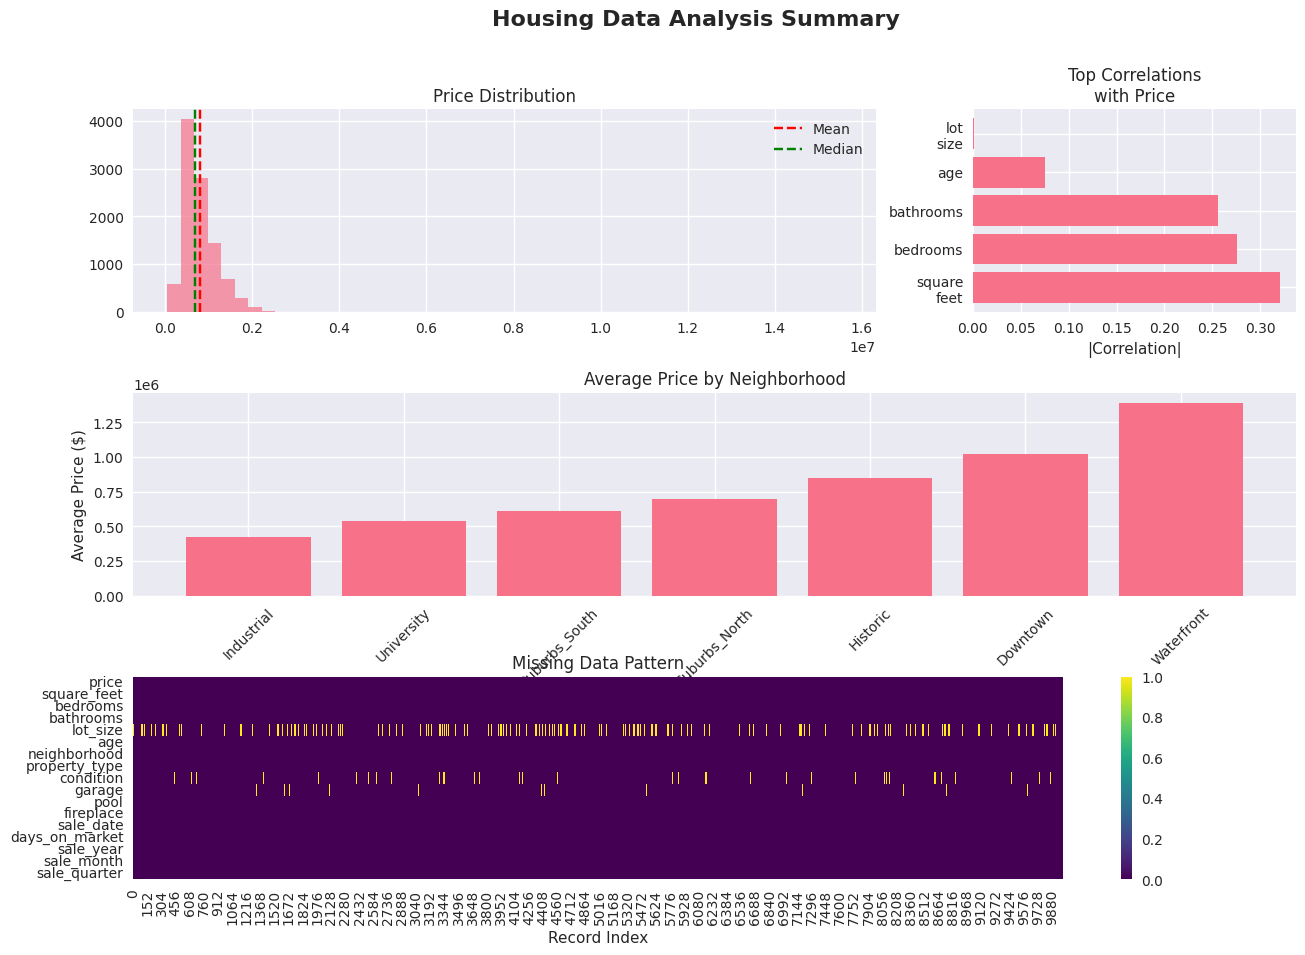


🎉 DATA EXPLORATION COMPLETE!

You now have a comprehensive understanding of your housing dataset.
The insights from this analysis will guide your feature engineering
and model selection in the next sections.

📚 Save this notebook as your project's data exploration reference!


In [11]:
def summarize_findings(df):
    """Summarize key findings and implications for model building."""
    
    print("🎯 KEY FINDINGS SUMMARY")
    print("=" * 50)
    
    # Key insights
    insights = []
    
    # Price insights
    median_price = df['price'].median()
    price_range = df['price'].max() - df['price'].min()
    insights.append(f"📊 Price Range: ${df['price'].min():,.0f} - ${df['price'].max():,.0f} (Median: ${median_price:,.0f})")
    
    # Feature importance insights
    numerical_cols = ['square_feet', 'lot_size', 'age', 'bedrooms', 'bathrooms']
    correlations = []
    for col in numerical_cols:
        if col in df.columns:
            corr = df[col].corr(df['price'])
            if not np.isnan(corr):
                correlations.append((col, abs(corr)))
    
    correlations.sort(key=lambda x: x[1], reverse=True)
    if correlations:
        top_feature = correlations[0]
        insights.append(f"🔗 Strongest predictor: {top_feature[0]} (correlation: {top_feature[1]:.3f})")
    
    # Neighborhood insights
    if 'neighborhood' in df.columns:
        neighborhood_prices = df.groupby('neighborhood')['price'].mean().sort_values(ascending=False)
        most_expensive = neighborhood_prices.index[0]
        least_expensive = neighborhood_prices.index[-1]
        price_difference = neighborhood_prices.iloc[0] - neighborhood_prices.iloc[-1]
        insights.append(f"🏘️ Location matters: {most_expensive} vs {least_expensive} (${price_difference:,.0f} difference)")
    
    # Data quality insights
    missing_percentage = (df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100
    insights.append(f"🔍 Data completeness: {100-missing_percentage:.1f}% ({missing_percentage:.1f}% missing)")
    
    # Print insights
    print("\n🔑 Key Insights:")
    for insight in insights:
        print(f"  {insight}")
    
    # Model building implications
    print(f"\n🤖 Implications for Model Building:")
    
    implications = [
        "Strong size-price correlation suggests linear models may work well",
        "Neighborhood effects indicate need for categorical encoding",
        "Some missing data - plan imputation strategy",
        "Price distribution may benefit from log transformation",
        "Temporal patterns suggest including date features"
    ]
    
    # Check specific conditions
    if df['price'].skew() > 1:
        implications.append("Right-skewed price distribution - consider log transformation")
    
    if any(df.select_dtypes(include=[np.number]).isnull().sum() > 0):
        implications.append("Missing numerical values - implement robust imputation")
    
    categorical_cols = df.select_dtypes(include=['object']).columns
    high_cardinality = [col for col in categorical_cols if df[col].nunique() > 10]
    if high_cardinality:
        implications.append(f"High cardinality features ({high_cardinality}) - consider embedding or grouping")
    
    for i, implication in enumerate(implications, 1):
        print(f"  {i}. {implication}")
    
    # Next steps
    print(f"\n🚀 Recommended Next Steps:")
    next_steps = [
        "Create data preprocessing pipeline",
        "Implement feature engineering based on insights",
        "Set up proper train/validation/test splits",
        "Establish baseline model performance",
        "Plan experiment tracking strategy",
        "Document data assumptions and limitations"
    ]
    
    for i, step in enumerate(next_steps, 1):
        print(f"  {i}. {step}")
    
    # Create a final visualization
    plt.figure(figsize=(15, 10))
    
    # Create a dashboard-style summary plot
    gs = plt.GridSpec(3, 3, hspace=0.4, wspace=0.3)
    
    # Price distribution
    ax1 = plt.subplot(gs[0, :2])
    df['price'].hist(bins=50, alpha=0.7, ax=ax1)
    ax1.axvline(df['price'].mean(), color='red', linestyle='--', label='Mean')
    ax1.axvline(df['price'].median(), color='green', linestyle='--', label='Median')
    ax1.set_title('Price Distribution')
    ax1.legend()
    
    # Top correlations
    ax2 = plt.subplot(gs[0, 2])
    if correlations:
        features = [c[0].replace('_', '\n') for c in correlations[:5]]
        corr_values = [c[1] for c in correlations[:5]]
        ax2.barh(features, corr_values)
        ax2.set_title('Top Correlations\nwith Price')
        ax2.set_xlabel('|Correlation|')
    
    # Neighborhood prices
    ax3 = plt.subplot(gs[1, :])
    if 'neighborhood' in df.columns:
        neighborhood_prices = df.groupby('neighborhood')['price'].mean().sort_values()
        ax3.bar(range(len(neighborhood_prices)), neighborhood_prices.values)
        ax3.set_title('Average Price by Neighborhood')
        ax3.set_xticks(range(len(neighborhood_prices)))
        ax3.set_xticklabels(neighborhood_prices.index, rotation=45)
        ax3.set_ylabel('Average Price ($)')
    
    # Missing data heatmap
    ax4 = plt.subplot(gs[2, :])
    missing_data = df.isnull()
    if missing_data.sum().sum() > 0:
        sns.heatmap(missing_data.T, yticklabels=True, cbar=True, ax=ax4, cmap='viridis')
        ax4.set_title('Missing Data Pattern')
        ax4.set_xlabel('Record Index')
    else:
        ax4.text(0.5, 0.5, 'No Missing Data', ha='center', va='center', transform=ax4.transAxes, fontsize=16)
        ax4.set_title('Missing Data Pattern')
    
    plt.suptitle('Housing Data Analysis Summary', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Generate summary
summarize_findings(df)

print("\n" + "="*60)
print("🎉 DATA EXPLORATION COMPLETE!")
print("="*60)
print("\nYou now have a comprehensive understanding of your housing dataset.")
print("The insights from this analysis will guide your feature engineering")
print("and model selection in the next sections.")
print("\n📚 Save this notebook as your project's data exploration reference!")

In [17]:
from typing import Dict, List, Tuple, Any
from dataclasses import dataclass
import pandas as pd
import numpy as np
from src.utils.logging import setup_logging

logger = setup_logging(__name__)

@dataclass
class ValidationRule:
    """Data validation rule definition."""
    name: str
    description: str
    severity: str  # 'error', 'warning', 'info'
    
class DataValidator:
    """Comprehensive data validation for housing data."""
    
    def __init__(self):
        self.rules = self._define_validation_rules()
        self.results = []
    
    def _define_validation_rules(self) -> List[ValidationRule]:
        """Define validation rules for housing data."""
        return [
            ValidationRule("price_range", "Price should be between $10K and $50M", "error"),
            ValidationRule("sqft_range", "Square feet should be between 100 and 50,000", "error"),
            ValidationRule("bedroom_range", "Bedrooms should be between 0 and 20", "warning"),
            ValidationRule("bathroom_range", "Bathrooms should be between 0.5 and 20", "warning"),
            ValidationRule("age_range", "Age should be between 0 and 300 years", "warning"),
            ValidationRule("missing_critical", "Critical fields shouldn't be missing", "error"),
            ValidationRule("logical_consistency", "Bedrooms/bathrooms should match property size", "warning"),
            ValidationRule("duplicate_records", "No duplicate property records allowed", "error"),
        ]
    
    def validate_price_range(self, df: pd.DataFrame) -> Dict[str, Any]:
        """Validate price values are within reasonable range."""
        price_issues = df[(df['price'] < 10000) | (df['price'] > 50000000)]
        
        return {
            'rule_name': 'price_range',
            'passed': len(price_issues) == 0,
            'issue_count': len(price_issues),
            'details': f"{len(price_issues)} properties with unrealistic prices",
            'severity': 'error' if len(price_issues) > 0 else 'info'
        }
    
    def validate_sqft_range(self, df: pd.DataFrame) -> Dict[str, Any]:
        """Validate square footage is reasonable."""
        sqft_issues = df[(df['square_feet'] < 100) | (df['square_feet'] > 50000)]
        
        return {
            'rule_name': 'sqft_range', 
            'passed': len(sqft_issues) == 0,
            'issue_count': len(sqft_issues),
            'details': f"{len(sqft_issues)} properties with unrealistic square footage",
            'severity': 'error' if len(sqft_issues) > 0 else 'info'
        }
    
    def validate_missing_critical(self, df: pd.DataFrame) -> Dict[str, Any]:
        """Check for missing values in critical columns."""
        critical_cols = ['price', 'square_feet', 'neighborhood']
        missing_critical = df[critical_cols].isnull().any(axis=1).sum()
        
        return {
            'rule_name': 'missing_critical',
            'passed': missing_critical == 0,
            'issue_count': missing_critical,
            'details': f"{missing_critical} records missing critical information",
            'severity': 'error' if missing_critical > 0 else 'info'
        }
    
    def validate_logical_consistency(self, df: pd.DataFrame) -> Dict[str, Any]:
        """Check for logical inconsistencies in the data."""
        issues = []
        
        # Check if bathrooms > bedrooms by a lot (might indicate data error)
        bathroom_issues = df[df['bathrooms'] > df['bedrooms'] * 2]
        if len(bathroom_issues) > 0:
            issues.append(f"{len(bathroom_issues)} properties with excessive bathrooms")
        
        # Check if square feet per bedroom is unreasonably small
        df['sqft_per_bedroom'] = df['square_feet'] / df['bedrooms'].replace(0, 1)
        small_rooms = df[df['sqft_per_bedroom'] < 50]
        if len(small_rooms) > 0:
            issues.append(f"{len(small_rooms)} properties with tiny bedrooms")
        
        return {
            'rule_name': 'logical_consistency',
            'passed': len(issues) == 0,
            'issue_count': len(issues),
            'details': '; '.join(issues) if issues else "No logical inconsistencies found",
            'severity': 'warning' if len(issues) > 0 else 'info'
        }
    
    def validate_duplicates(self, df: pd.DataFrame) -> Dict[str, Any]:
        """Check for duplicate records."""
        # Consider records duplicates if they have same address and sale_date
        # For this synthetic data, we'll check for exact duplicates
        duplicates = df.duplicated().sum()
        
        return {
            'rule_name': 'duplicate_records',
            'passed': duplicates == 0,
            'issue_count': duplicates,
            'details': f"{duplicates} duplicate records found",
            'severity': 'error' if duplicates > 0 else 'info'
        }
    
    def run_validation(self, df: pd.DataFrame) -> Dict[str, Any]:
        """Run all validation checks and return comprehensive report."""
        
        logger.info("Starting data validation...")
        
        validation_results = []
        
        # Run each validation check
        validation_results.append(self.validate_price_range(df))
        validation_results.append(self.validate_sqft_range(df))
        validation_results.append(self.validate_missing_critical(df))
        validation_results.append(self.validate_logical_consistency(df))
        validation_results.append(self.validate_duplicates(df))
        
        # Summarize results
        errors = [r for r in validation_results if r['severity'] == 'error' and not r['passed']]
        warnings = [r for r in validation_results if r['severity'] == 'warning' and not r['passed']]
        
        validation_summary = {
            'total_checks': len(validation_results),
            'passed_checks': len([r for r in validation_results if r['passed']]),
            'errors': len(errors),
            'warnings': len(warnings),
            'validation_results': validation_results,
            'overall_status': 'PASS' if len(errors) == 0 else 'FAIL'
        }
        
        # Log summary
        logger.info("Validation complete: %s", validation_summary['overall_status'])
        logger.info("Checks passed: %s/%s", validation_summary['passed_checks'], validation_summary['total_checks'])
        if errors:
            logger.error("Found %d critical errors", len(errors))
        if warnings:
            logger.warning("Found %d warnings", len(warnings))
        
        return validation_summary

def run_data_validation_example():
    """Example of how to use the data validation framework."""

    # Load data
    from src.data.load_data import load_housing_data
    df = load_housing_data()
    
    # Run validation
    validator = DataValidator()
    results = validator.run_validation(df)
    
    # Print results
    print("🔍 DATA VALIDATION RESULTS")
    print("=" * 40)
    print(f"Overall Status: {results['overall_status']}")
    print(f"Checks Passed: {results['passed_checks']}/{results['total_checks']}")
    print(f"Errors: {results['errors']}")
    print(f"Warnings: {results['warnings']}")
    
    print("\n📋 Detailed Results:")
    for result in results['validation_results']:
        status = "✅" if result['passed'] else "❌" if result['severity'] == 'error' else "⚠️"
        print(f"{status} {result['rule_name']}: {result['details']}")

run_data_validation_example()

2025-07-28 16:15:51,306 - src.data.load_data - INFO - Loading housing data from data/raw/housing_data.csv
2025-07-28 16:15:51,330 - src.data.load_data - INFO - Loaded 10000 records with 14 columns
2025-07-28 16:15:51,331 - __main__ - INFO - Starting data validation...
2025-07-28 16:15:51,339 - __main__ - INFO - Validation complete: PASS
2025-07-28 16:15:51,340 - __main__ - INFO - Checks passed: 4/5
2025-07-28 16:15:51,341 - __main__ - WARNING - Found 1 warnings
🔍 DATA VALIDATION RESULTS
Overall Status: PASS
Checks Passed: 4/5
Errors: 0
Warnings: 1

📋 Detailed Results:
✅ price_range: 0 properties with unrealistic prices
✅ sqft_range: 0 properties with unrealistic square footage
✅ missing_critical: 0 records missing critical information
⚠️ logical_consistency: 1 properties with excessive bathrooms; 1 properties with tiny bedrooms
✅ duplicate_records: 0 duplicate records found


In [18]:
def perform_statistical_tests(df):
    """Perform statistical tests to validate key hypotheses about the data."""
    
    print("🧪 STATISTICAL HYPOTHESIS TESTING")
    print("=" * 50)
    
    from scipy import stats
    
    # Test 1: Do different neighborhoods have significantly different prices?
    print("\n📊 Test 1: Neighborhood Price Differences")
    print("H0: All neighborhoods have the same average price")
    print("H1: At least one neighborhood has different average price")
    
    neighborhood_groups = [group['price'].values for name, group in df.groupby('neighborhood')]
    f_stat, p_value = stats.f_oneway(*neighborhood_groups)
    
    print(f"F-statistic: {f_stat:.3f}")
    print(f"P-value: {p_value:.2e}")
    
    if p_value < 0.05:
        print("✅ Result: Reject H0 - Neighborhoods have significantly different prices")
    else:
        print("❌ Result: Fail to reject H0 - No significant price differences")
    
    # Test 2: Is there a linear relationship between size and price?
    print("\n📈 Test 2: Size-Price Correlation Significance")
    print("H0: No correlation between square feet and price")
    print("H1: Significant correlation exists")
    
    correlation, p_value = stats.pearsonr(df['square_feet'].dropna(), 
                                        df['price'][df['square_feet'].dropna().index])
    
    print(f"Correlation coefficient: {correlation:.3f}")
    print(f"P-value: {p_value:.2e}")
    
    if p_value < 0.05:
        print("✅ Result: Significant correlation between size and price")
    else:
        print("❌ Result: No significant correlation")
    
    # Test 3: Price distribution normality
    print("\n📊 Test 3: Price Distribution Normality")
    print("H0: Prices are normally distributed")
    print("H1: Prices are not normally distributed")
    
    stat, p_value = stats.shapiro(df['price'].sample(5000) if len(df) > 5000 else df['price'])
    
    print(f"Shapiro-Wilk statistic: {stat:.3f}")
    print(f"P-value: {p_value:.2e}")
    
    if p_value < 0.05:
        print("❌ Result: Prices are NOT normally distributed")
        print("💡 Implication: Consider log transformation for modeling")
    else:
        print("✅ Result: Prices appear normally distributed")
    
    # Test 4: Do properties with pools have higher prices?
    print("\n🏊 Test 4: Pool Effect on Price")
    print("H0: Pool doesn't affect price")
    print("H1: Pool significantly affects price")
    
    pool_prices = df[df['pool'] == 1]['price']
    no_pool_prices = df[df['pool'] == 0]['price']
    
    stat, p_value = stats.ttest_ind(pool_prices, no_pool_prices)
    
    pool_mean = pool_prices.mean()
    no_pool_mean = no_pool_prices.mean()
    
    print(f"Average price with pool: ${pool_mean:,.0f}")
    print(f"Average price without pool: ${no_pool_mean:,.0f}")
    print(f"Difference: ${pool_mean - no_pool_mean:,.0f}")
    print(f"T-statistic: {stat:.3f}")
    print(f"P-value: {p_value:.2e}")
    
    if p_value < 0.05:
        print("✅ Result: Pool significantly affects price")
    else:
        print("❌ Result: No significant pool effect")

perform_statistical_tests(df)

🧪 STATISTICAL HYPOTHESIS TESTING

📊 Test 1: Neighborhood Price Differences
H0: All neighborhoods have the same average price
H1: At least one neighborhood has different average price
F-statistic: 1955.199
P-value: 0.00e+00
✅ Result: Reject H0 - Neighborhoods have significantly different prices

📈 Test 2: Size-Price Correlation Significance
H0: No correlation between square feet and price
H1: Significant correlation exists
Correlation coefficient: 0.321
P-value: 1.31e-238
✅ Result: Significant correlation between size and price

📊 Test 3: Price Distribution Normality
H0: Prices are normally distributed
H1: Prices are not normally distributed
Shapiro-Wilk statistic: 0.915
P-value: 0.00e+00
❌ Result: Prices are NOT normally distributed
💡 Implication: Consider log transformation for modeling

🏊 Test 4: Pool Effect on Price
H0: Pool doesn't affect price
H1: Pool significantly affects price
Average price with pool: $845,938
Average price without pool: $779,999
Difference: $65,939
T-statistic

📊 ADVANCED VISUALIZATION ANALYSIS


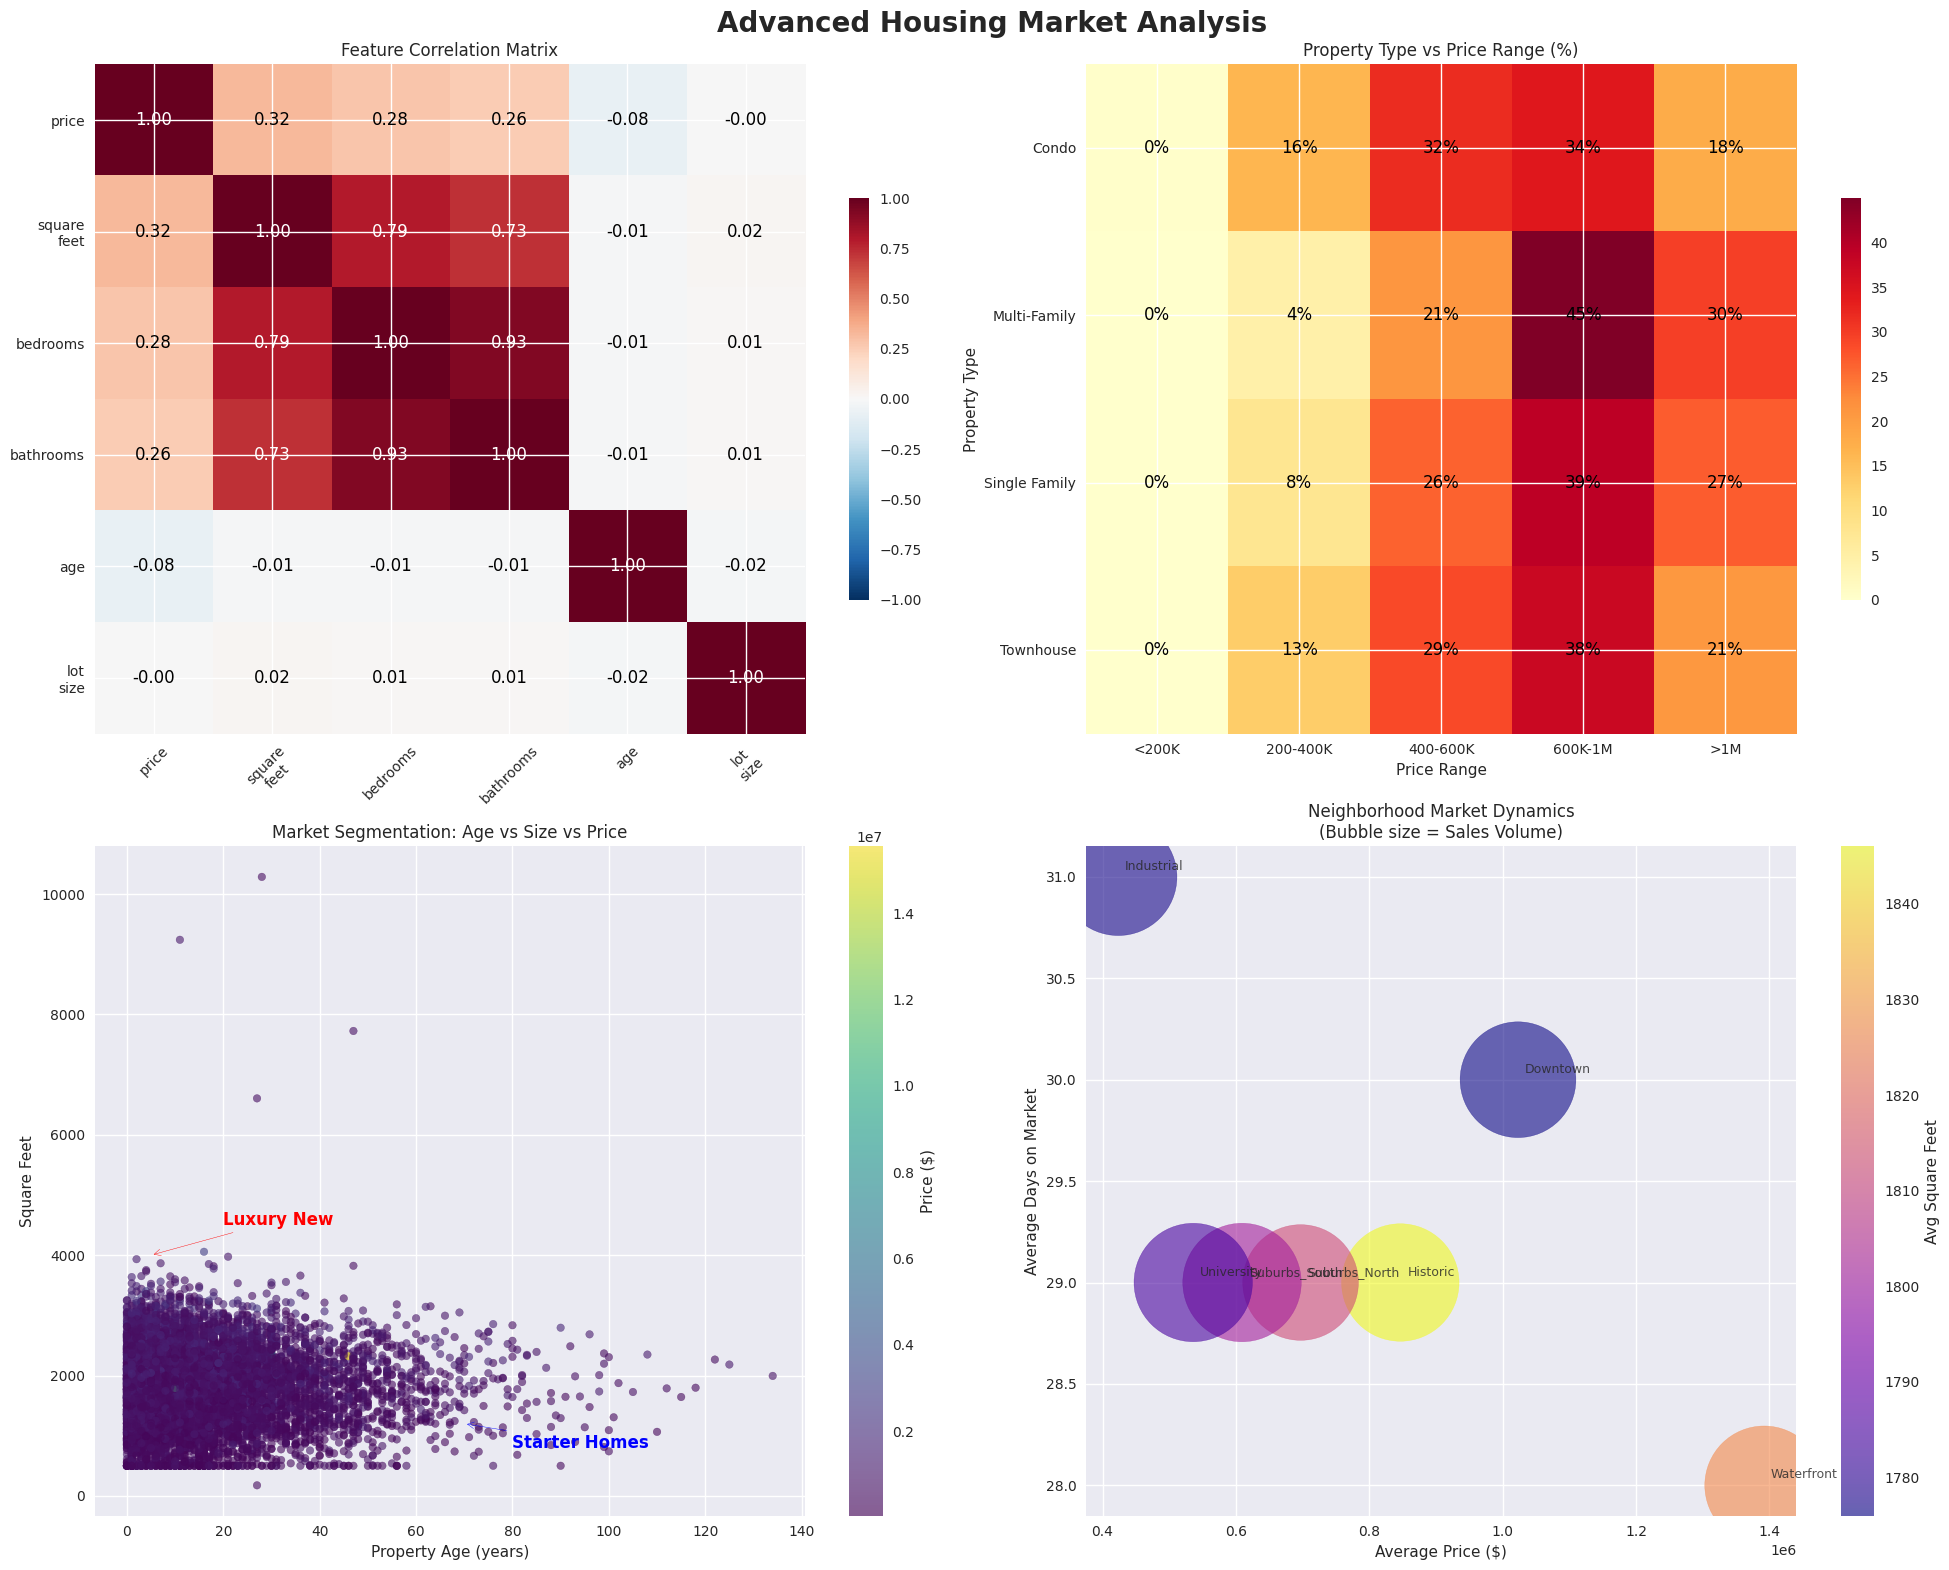


💡 Advanced Analysis Insights:
⚖️ Price doesn't strongly affect time on market (correlation: -0.016)
🏠 Small homes have 66.0% price premium per square foot


In [19]:
def create_advanced_visualizations(df):
    """Create advanced visualizations for deeper insights."""
    
    print("📊 ADVANCED VISUALIZATION ANALYSIS")
    print("=" * 50)
    
    # 1. Correlation Network
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('Advanced Housing Market Analysis', fontsize=20, fontweight='bold')
    
    # Correlation network (chord diagram alternative)
    numerical_cols = ['price', 'square_feet', 'bedrooms', 'bathrooms', 'age', 'lot_size']
    corr_matrix = df[numerical_cols].corr()
    
    # Create a network-style correlation plot
    ax1 = axes[0, 0]
    im = ax1.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax1.set_xticks(range(len(numerical_cols)))
    ax1.set_yticks(range(len(numerical_cols)))
    ax1.set_xticklabels([col.replace('_', '\n') for col in numerical_cols], rotation=45)
    ax1.set_yticklabels([col.replace('_', '\n') for col in numerical_cols])
    ax1.set_title('Feature Correlation Matrix')
    
    # Add correlation values
    for i in range(len(numerical_cols)):
        for j in range(len(numerical_cols)):
            text = ax1.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                           ha="center", va="center", color="black" if abs(corr_matrix.iloc[i, j]) < 0.5 else "white")
    
    plt.colorbar(im, ax=ax1, shrink=0.6)
    
    # 2. Price Distribution by Multiple Factors
    ax2 = axes[0, 1]
    
    # Create price ranges for better visualization
    df['price_range'] = pd.cut(df['price'], 
                              bins=[0, 200000, 400000, 600000, 1000000, float('inf')],
                              labels=['<200K', '200-400K', '400-600K', '600K-1M', '>1M'])
    
    # Cross-tabulation of property type and price range
    crosstab = pd.crosstab(df['property_type'], df['price_range'])
    crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    
    im2 = ax2.imshow(crosstab_pct.values, cmap='YlOrRd', aspect='auto')
    ax2.set_xticks(range(len(crosstab_pct.columns)))
    ax2.set_yticks(range(len(crosstab_pct.index)))
    ax2.set_xticklabels(crosstab_pct.columns)
    ax2.set_yticklabels(crosstab_pct.index)
    ax2.set_title('Property Type vs Price Range (%)')
    ax2.set_xlabel('Price Range')
    ax2.set_ylabel('Property Type')
    
    # Add percentage values
    for i in range(len(crosstab_pct.index)):
        for j in range(len(crosstab_pct.columns)):
            text = ax2.text(j, i, f'{crosstab_pct.iloc[i, j]:.0f}%',
                           ha="center", va="center", 
                           color="white" if crosstab_pct.iloc[i, j] > 50 else "black")
    
    plt.colorbar(im2, ax=ax2, shrink=0.6)
    
    # 3. Market Segmentation Analysis
    ax3 = axes[1, 0]
    
    # Create size vs age scatter with price color coding
    scatter = ax3.scatter(df['age'], df['square_feet'], 
                         c=df['price'], cmap='viridis', 
                         alpha=0.6, s=30)
    ax3.set_xlabel('Property Age (years)')
    ax3.set_ylabel('Square Feet')
    ax3.set_title('Market Segmentation: Age vs Size vs Price')
    plt.colorbar(scatter, ax=ax3, label='Price ($)')
    
    # Add market segment annotations
    # New luxury homes
    luxury_new = df[(df['age'] < 10) & (df['square_feet'] > 3000)]
    if len(luxury_new) > 0:
        ax3.annotate('Luxury New', xy=(5, 4000), xytext=(20, 4500),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    fontsize=12, fontweight='bold', color='red')
    
    # Older smaller homes
    older_small = df[(df['age'] > 50) & (df['square_feet'] < 1500)]
    if len(older_small) > 0:
        ax3.annotate('Starter Homes', xy=(70, 1200), xytext=(80, 800),
                    arrowprops=dict(arrowstyle='->', color='blue'),
                    fontsize=12, fontweight='bold', color='blue')
    
    # 4. Neighborhood Market Analysis
    ax4 = axes[1, 1]
    
    # Calculate market metrics by neighborhood
    neighborhood_stats = df.groupby('neighborhood').agg({
        'price': ['mean', 'count'],
        'days_on_market': 'mean',
        'square_feet': 'mean'
    }).round(0)
    
    neighborhood_stats.columns = ['avg_price', 'volume', 'avg_days_market', 'avg_size']
    neighborhood_stats = neighborhood_stats.reset_index()
    
    # Create bubble chart: x=avg_price, y=avg_days_market, size=volume
    bubbles = ax4.scatter(neighborhood_stats['avg_price'], 
                         neighborhood_stats['avg_days_market'],
                         s=neighborhood_stats['volume']*5,  # Scale bubble size
                         alpha=0.6, c=neighborhood_stats['avg_size'], 
                         cmap='plasma')
    
    ax4.set_xlabel('Average Price ($)')
    ax4.set_ylabel('Average Days on Market')
    ax4.set_title('Neighborhood Market Dynamics\n(Bubble size = Sales Volume)')
    
    # Add neighborhood labels
    for idx, row in neighborhood_stats.iterrows():
        ax4.annotate(row['neighborhood'], 
                    (row['avg_price'], row['avg_days_market']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, alpha=0.8)
    
    plt.colorbar(bubbles, ax=ax4, label='Avg Square Feet')
    
    plt.tight_layout()
    plt.show()
    
    # Additional insights
    print("\n💡 Advanced Analysis Insights:")
    
    # Market efficiency insight
    price_dom_corr = df['price'].corr(df['days_on_market'])
    if price_dom_corr < -0.1:
        print(f"📈 Higher priced homes sell faster (correlation: {price_dom_corr:.3f})")
    elif price_dom_corr > 0.1:
        print(f"📉 Higher priced homes take longer to sell (correlation: {price_dom_corr:.3f})")
    else:
        print(f"⚖️ Price doesn't strongly affect time on market (correlation: {price_dom_corr:.3f})")
    
    # Size premium analysis
    small_homes = df[df['square_feet'] < 1500]['price'] / df[df['square_feet'] < 1500]['square_feet']
    large_homes = df[df['square_feet'] > 3000]['price'] / df[df['square_feet'] > 3000]['square_feet']
    
    small_price_per_sqft = small_homes.median()
    large_price_per_sqft = large_homes.median()
    
    if large_price_per_sqft > small_price_per_sqft:
        premium = ((large_price_per_sqft - small_price_per_sqft) / small_price_per_sqft) * 100
        print(f"🏰 Large homes have {premium:.1f}% price premium per square foot")
    else:
        discount = ((small_price_per_sqft - large_price_per_sqft) / large_price_per_sqft) * 100
        print(f"🏠 Small homes have {discount:.1f}% price premium per square foot")

create_advanced_visualizations(df)

📋 EXECUTIVE SUMMARY

📊 MARKET ANALYSIS EXECUTIVE SUMMARY

🏠 DATASET OVERVIEW
• Property Sales Analyzed: 10,000
• Market Coverage: 7 neighborhoods, 4 property types
• Analysis Period: 1094 days (Jul 2022 - Jul 2025)
• Data Completeness: 98.7%

💰 PRICE ANALYSIS
• Average Sale Price: $789,982
• Median Sale Price: $693,725
• Price Range: $44,383 - $15,547,840
• Market Variation: $15,503,457 spread

🔍 KEY MARKET DRIVERS
• Property Size Impact: 32.1% correlation with price
• Age Effect: Age neutral pricing
• Location Premium: Up to $968,613 between neighborhoods

📈 MARKET DYNAMICS
• Average Time on Market: 29 days
• Market Velocity: Fast-moving market
• Inventory Characteristics: Single Family homes dominate (59%)

⚠️ DATA QUALITY ASSESSMENT
• Missing Data: 2304 total missing values
• Outliers Identified: 587 properties
• Data Reliability: Requires attention

🎯 MODELING READINESS
• Feature Correlations: Strong size-price relationship suitable for linear models
• Data Distribution: Skewed dis

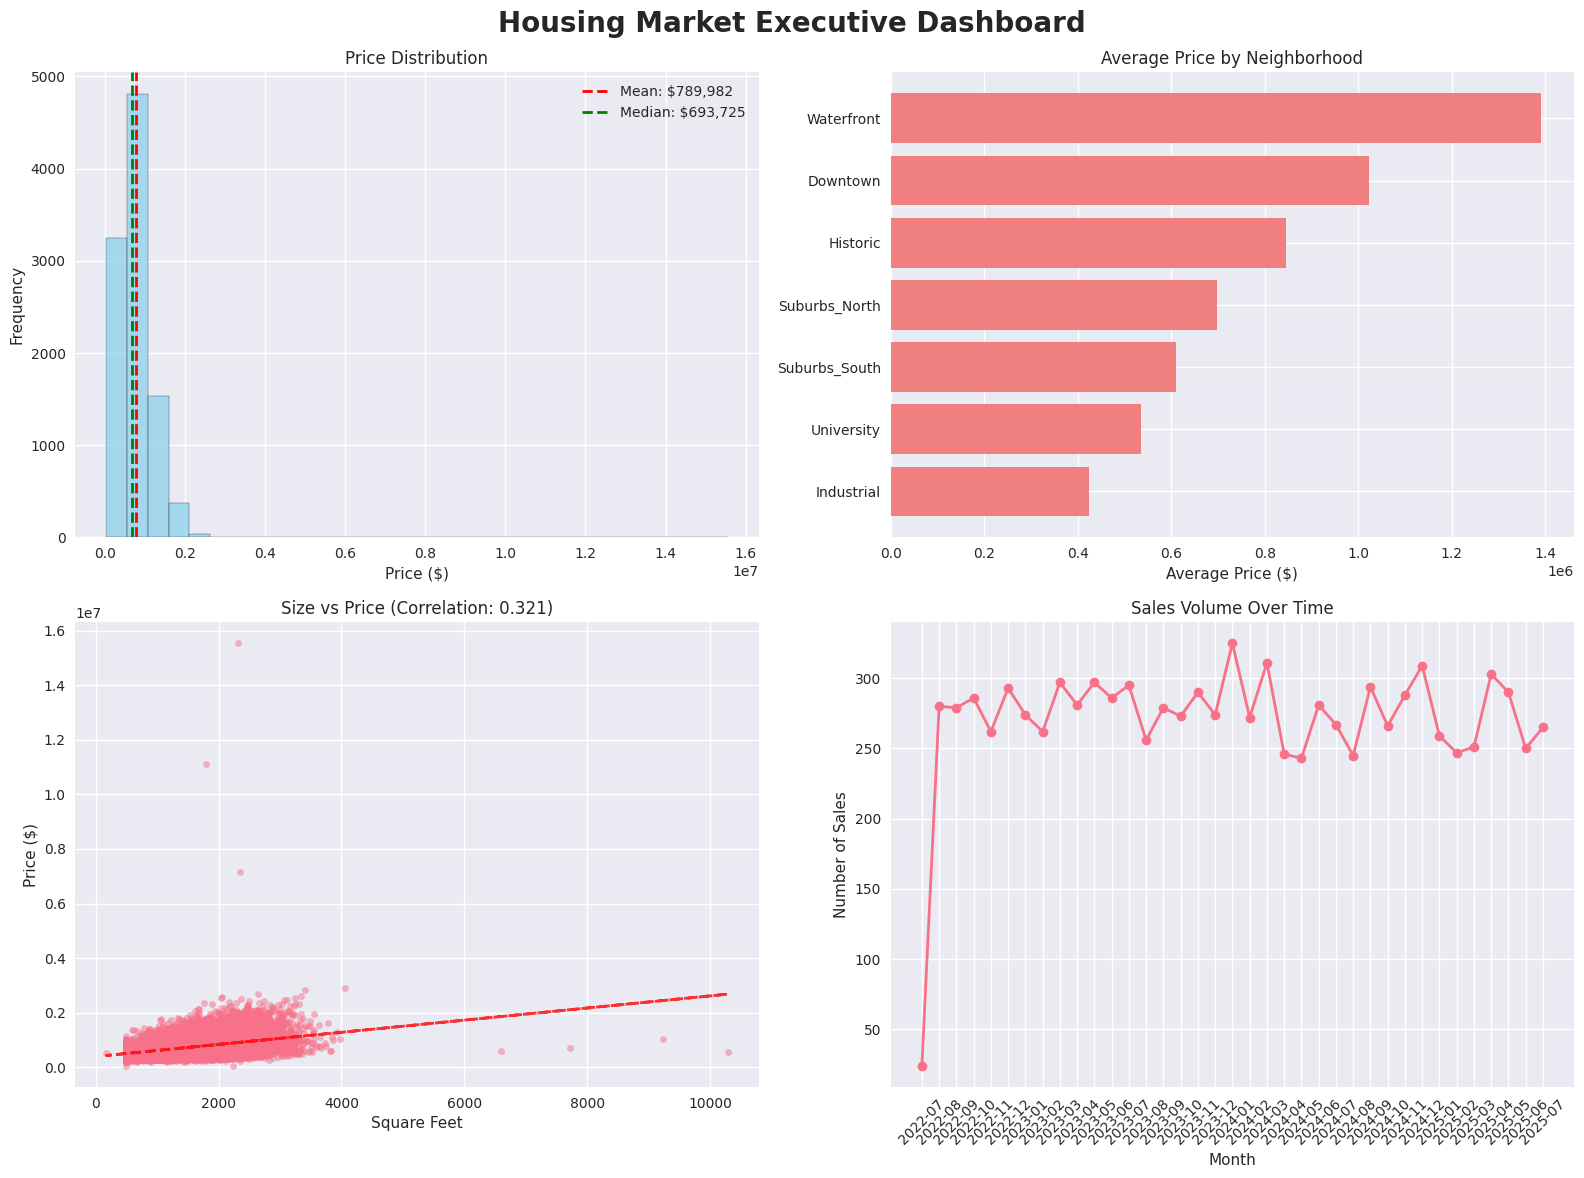

In [20]:
def generate_executive_summary(df):
    """Generate a professional executive summary of findings."""
    
    print("📋 EXECUTIVE SUMMARY")
    print("=" * 60)
    
    # Key metrics
    total_properties = len(df)
    avg_price = df['price'].mean()
    median_price = df['price'].median()
    price_range = df['price'].max() - df['price'].min()
    
    # Market insights
    neighborhoods = len(df['neighborhood'].unique())
    property_types = len(df['property_type'].unique())
    
    # Time span
    date_range = (df['sale_date'].max() - df['sale_date'].min()).days
    
    # Correlation insights
    size_price_corr = df['square_feet'].corr(df['price'])
    age_price_corr = df['age'].corr(df['price'])
    
    # Generate professional summary
    summary = f"""
📊 MARKET ANALYSIS EXECUTIVE SUMMARY
{'='*60}

🏠 DATASET OVERVIEW
• Property Sales Analyzed: {total_properties:,}
• Market Coverage: {neighborhoods} neighborhoods, {property_types} property types
• Analysis Period: {date_range} days ({df['sale_date'].min().strftime('%b %Y')} - {df['sale_date'].max().strftime('%b %Y')})
• Data Completeness: {(1 - df.isnull().sum().sum()/(len(df)*len(df.columns)))*100:.1f}%

💰 PRICE ANALYSIS
• Average Sale Price: ${avg_price:,.0f}
• Median Sale Price: ${median_price:,.0f}
• Price Range: ${df['price'].min():,.0f} - ${df['price'].max():,.0f}
• Market Variation: ${price_range:,.0f} spread

🔍 KEY MARKET DRIVERS
• Property Size Impact: {abs(size_price_corr):.1%} correlation with price
• Age Effect: {'Newer homes premium' if age_price_corr < -0.1 else 'Age neutral pricing' if abs(age_price_corr) < 0.1 else 'Vintage premium'}
• Location Premium: Up to ${df.groupby('neighborhood')['price'].mean().max() - df.groupby('neighborhood')['price'].mean().min():,.0f} between neighborhoods

📈 MARKET DYNAMICS
• Average Time on Market: {df['days_on_market'].mean():.0f} days
• Market Velocity: {'Fast-moving' if df['days_on_market'].median() < 30 else 'Moderate' if df['days_on_market'].median() < 60 else 'Slow-moving'} market
• Inventory Characteristics: {df['property_type'].value_counts().index[0]} homes dominate ({df['property_type'].value_counts().iloc[0]/len(df)*100:.0f}%)

⚠️ DATA QUALITY ASSESSMENT
• Missing Data: {df.isnull().sum().sum()} total missing values
• Outliers Identified: {len(df[(np.abs(stats.zscore(df.select_dtypes(include=[np.number]), nan_policy='omit')) > 3).any(axis=1)])} properties
• Data Reliability: {'High' if df.isnull().sum().sum() < len(df)*0.05 else 'Moderate' if df.isnull().sum().sum() < len(df)*0.15 else 'Requires attention'}

🎯 MODELING READINESS
• Feature Correlations: Strong size-price relationship suitable for linear models
• Data Distribution: {'Normal distribution' if abs(df['price'].skew()) < 1 else 'Skewed distribution - consider transformation'}
• Geographic Diversity: {neighborhoods} neighborhoods provide location variety
• Temporal Coverage: {date_range/365:.1f} years of market data

💡 KEY RECOMMENDATIONS
1. {'Implement log transformation for price modeling' if df['price'].skew() > 1 else 'Price distribution suitable for direct modeling'}
2. {'Address missing data through imputation strategy' if df.isnull().sum().sum() > 0 else 'Data is complete and ready for modeling'}
3. Feature engineering opportunities in location and property characteristics
4. Strong foundation for predictive modeling with {abs(size_price_corr):.1%} size-price correlation
5. Consider neighborhood-specific models given location premium variance

📚 BUSINESS IMPLICATIONS
• Market Segmentation: Clear differentiation between neighborhoods and property types
• Pricing Strategy: Size and location are primary value drivers
• Investment Opportunity: {'Undervalued segments identified' if df.groupby('neighborhood')['price'].mean().std() > 50000 else 'Market appears efficiently priced'}
• Model Applicability: Dataset suitable for automated valuation modeling

"""
    
    print(summary)
    
    # Create a one-page visual summary
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Housing Market Executive Dashboard', fontsize=20, fontweight='bold')
    
    # Price distribution with key stats
    ax1.hist(df['price'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(avg_price, color='red', linestyle='--', linewidth=2, label=f'Mean: ${avg_price:,.0f}')
    ax1.axvline(median_price, color='green', linestyle='--', linewidth=2, label=f'Median: ${median_price:,.0f}')
    ax1.set_title('Price Distribution')
    ax1.set_xlabel('Price ($)')
    ax1.set_ylabel('Frequency')
    ax1.legend()
    
    # Neighborhood comparison
    neighborhood_prices = df.groupby('neighborhood')['price'].mean().sort_values(ascending=True)
    ax2.barh(range(len(neighborhood_prices)), neighborhood_prices.values, color='lightcoral')
    ax2.set_yticks(range(len(neighborhood_prices)))
    ax2.set_yticklabels(neighborhood_prices.index)
    ax2.set_title('Average Price by Neighborhood')
    ax2.set_xlabel('Average Price ($)')
    
    # Size vs Price relationship
    ax3.scatter(df['square_feet'], df['price'], alpha=0.5, s=20)
    z = np.polyfit(df['square_feet'], df['price'], 1)
    p = np.poly1d(z)
    ax3.plot(df['square_feet'], p(df['square_feet']), "r--", alpha=0.8, linewidth=2)
    ax3.set_title(f'Size vs Price (Correlation: {size_price_corr:.3f})')
    ax3.set_xlabel('Square Feet')
    ax3.set_ylabel('Price ($)')
    
    # Market timing
    monthly_volume = df.groupby(df['sale_date'].dt.to_period('M')).size()
    ax4.plot(monthly_volume.index.astype(str), monthly_volume.values, marker='o', linewidth=2)
    ax4.set_title('Sales Volume Over Time')
    ax4.set_xlabel('Month')
    ax4.set_ylabel('Number of Sales')
    ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

generate_executive_summary(df)